In [1]:
import numpy as np
import pandas as pd
import awkward as ak
import uproot
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from IPython.display import Image, display

import gc
import itertools

In [3]:
#base_path = "../../mnt/SingleTrackTrees/Simulation/alice_sim_2024_LHC24h1_1_536237_AOD"
base_path = "/home/pira/Documenti/PoD/LCP/LCP_B/ALICE"
which_chunk = ["001_010", "011_020", "021_030", "031_040", "041_050", "051_060", "061_070", "071_080", "081_090", "091_100" ]
which_file = "AO2DtreeMC.root"

In [4]:
def to_global_coord( row ):
    xy_in = np.array([row["fX"],row["fY"]])
    # angle = -row["fAlpha"]
    # rot = np.array([[np.cos(angle),np.sin(angle)], [-np.sin(angle), np.cos(angle)]]) # inverse matrix of the one from to_track_coord (-alfa)
    # Rewriting the above matrix using cosine/sin even/odd function properties: less multiplications
    angle = row["fAlpha"]
    rot = np.array([[np.cos(angle),-np.sin(angle)], [np.sin(angle), np.cos(angle)]])
    xy_out = rot.dot(xy_in)
    return( xy_out )

def secondary_vertex ( row1, row2 ):
    XY1, XY2 = [to_global_coord(row1), to_global_coord(row2)]
    x1 = XY1[0]
    y1 = XY1[1]
    x2 = XY2[0]
    y2 = XY2[1]
    
    px1 = row1["px"]
    px2 = row2["px"]
    py1 = row1["py"]
    py2 = row2["py"]
    pz1 = row1["pz"]
    pz2 = row2["pz"]
    
    m1 = py1/px1
    m2 = py2/px2
    q1 = y1 - m1*x1
    q2 = y2 - m2*x2
    x_SV = ( q2 - q1 )/( m1 - m2)
    y_SV = y1 + m1*(x_SV - x1)

    # NEW: Benedetto's fix
    z1_track = pz1/px1 * (x_SV - x1) + row1["fZ"]
    z2_track = pz2/px2 * (x_SV - x2) + row2["fZ"]
    z_SV = (z1_track + z2_track)/2
    return ([x_SV, y_SV, z_SV])

# Particle masses in GeV
m_K = 0.493677
m_pi = 0.139570
m_d0 = 1.86484

$$
\begin{align}
D^0 \rightarrow K^- \quad \pi^+ \\
421 \rightarrow -321 \quad211
\end{align}
$$


$$
\begin{align}
\overline{D^0} \rightarrow& \quad K^+ \qquad \pi^- \\
-421 \rightarrow& +321 \quad-211
\end{align}
$$

In [5]:
# NSigmaTPC:
sigma_limit = 3
cut1 = (
    "( (fNsigmaTPCpi > -3) & (fNsigmaTPCpi < 3) & (fCharge == 1) ) | "
    "( (fNsigmaTPCka > -3) & (fNsigmaTPCka < 3) & (fCharge == -1) ) | "
    "( (fPt > 0) & (fPt < 1) & (fNsigmaTPCka > -15) & (fNsigmaTPCka < 0) & (fCharge == 1) )"
)

# NsigmaTOF:
sigma_limit = 3
cut2 = (
    "( (fNsigmaTOFpi > -3) & (fNsigmaTOFpi < 3) & (fCharge == 1) ) | "
    "( (fNsigmaTOFka > -3) & (fNsigmaTOFka < 3) & (fCharge == -1) ) | "
    "( (fNsigmaTOFka > 998.5) | (fNsigmaTOFka < -998.5) | (fNsigmaTOFpi > 998.5) | (fNsigmaTOFpi < -998.5) ) | "
    "( (fPt > 0) & (fPt < 3) & (fNsigmaTOFka > -50) & (fNsigmaTOFka < 0) & (fCharge == 1) )"
)

# DCA_XY:
cut3 = "( (fDcaXY > 0.0002) | (fDcaXY < -0.0002) )"


# FINAL CUT EXPRESSION:
cut_expression = f"({cut1}) & ({cut2}) & ({cut3})"

In [6]:
collision_offset = 0          # variable to correct the index of the collision (because it starts from 0 at each new TTree)
filtered_dfs = []

for chunk in range(1):
    path = base_path + "/".join(["/", which_file])
    file = uproot.open(path)

    names_track_extr = file.keys(filter_name=r"*O2filtertrackextr")
    names_track      = file.keys(filter_name=r"*O2filtertrack")
    names_coll       = file.keys(filter_name=r"*O2collision_001")
    
    names_mc_gen     = file.keys(filter_name=r"*O2genparticles")
    names_mc_track   = file.keys(filter_name=r"*O2filtertrackmc")
    names_mc_coll    = file.keys(filter_name=r"*O2mccollision")

    list_of_df = []               # add the dataframes in a list (we will concat them later)

    for i in range (len(names_coll)):
        # Read collision tree
        df_coll = file[ names_coll[i] ].arrays(["fPosX", "fPosY", "fPosZ"], library="pd")   # I take the fPosZ column as a DataFrame
    
        # # Read track and trackextr using boolean mask for track and trackextr:
        df_trackextr = file[ names_track_extr[i] ].arrays(["fPt", "fEta", "fCharge", "fDcaXY",
             "fNsigmaTPCpi", "fNsigmaTPCka", "fNsigmaTPCpr", "fNsigmaTOFpi", "fNsigmaTOFka"], library="pd" )
        df_track = file[ names_track[i] ].arrays(["fIndexCollisions", "fAlpha", "fX", "fY", "fZ"], library="pd")
    
        # take the corresponding data of MC
        df_track_mc = file[names_mc_track[i]].arrays(["fPdgCode","fMainMotherOrigIndex","fMainHfMotherPdgCode","fMainMotherNfinalStateDaught",
                                                      "fMainBeautyAncestorPdgCode"],library="pd")
        df_track = pd.merge(left=df_track, 
                             right=df_track_mc, 
                             how='inner', left_index=True, right_index=True)
    
        # merge all rows
        df_trackextr = pd.merge(left=df_trackextr, right=df_track, how='inner', left_index=True, right_index=True)
    
        # keep all particles that come from D0 AND are either K- or pi+ AND fMainBeautyAncestor = 0
        # For D0
        #is_D0 = (df_trackextr["fMainHfMotherPdgCode"]  == +421) & (df_trackextr["fPdgCode"].isin([-321,+211]) ) & \
        #(df_trackextr["fMainBeautyAncestorPdgCode"]==0)
        
        #is_anti_D0 = (df_trackextr["fMainHfMotherPdgCode"]  == -421) & (df_trackextr["fPdgCode"].isin([+321,-211]) ) & \
        #(df_trackextr["fMainBeautyAncestorPdgCode"]==0)
        #df_trackextr = df_trackextr[is_D0 | is_anti_D0]
    
        # keep only those with 2 or more daughter
        #df_trackextr = df_trackextr[df_trackextr["fMainMotherNfinalStateDaught"] >= 2]
    
        # mask = df_trackextr.eval(cut_expression)        # create boolean mask
        # # Apply the SAME filter to df_trackextr and df_track to keep them aligned (and keep only useful columns):
        # df_trackextr = df_trackextr.loc[mask, ["fIndexCollisions","fAlpha", "fX", "fY", "fZ","fPt", "fEta",
        #                                        "fCharge", "fDcaXY","fPdgCode"] ].reset_index(drop=True)

        # NEW: We keep the variables over which we did the cut to see how they behave for the signal
        df_trackextr = df_trackextr[["fIndexCollisions","fMainMotherOrigIndex","fAlpha", "fX", "fY", "fZ","fPt", "fEta", "fCharge", "fDcaXY","fMainHfMotherPdgCode",
                                     "fPdgCode","fNsigmaTPCpi", "fNsigmaTPCka","fNsigmaTOFpi", "fNsigmaTOFka", "fMainBeautyAncestorPdgCode"]]
    
        # we cut rows where the fIndexCollision is negative (for some reason)
        valid = df_trackextr["fIndexCollisions"] >= 0
        df_trackextr = df_trackextr[valid].reset_index(drop=True)  
    
        
        # Now we for correct fPosZ (and add that column)
        df_trackextr["fPosZ"] = df_coll.iloc[df_trackextr["fIndexCollisions"].values]["fPosZ"].values
      
        df_trackextr["fPosX"] = df_coll.iloc[df_trackextr["fIndexCollisions"].values]["fPosX"].values
    
        df_trackextr["fPosY"] = df_coll.iloc[df_trackextr["fIndexCollisions"].values]["fPosY"].values
    
        df_trackextr = df_trackextr[(df_trackextr["fPosZ"] < 10) & (df_trackextr["fPosZ"] > -10)].reset_index(drop=True)
        df_trackextr["fIndexCollisions"] += collision_offset   # Fix local fIndexCollisions → global index
        df_trackextr["fMainMotherOrigIndex"] += collision_offset
        
        # save results:
        # ALTERNATIVE 1: for the first cycle, let's copy the first dataframe, then we concatenate the next ones
        # if  i==0: df = df_trackextr
        # else: df = pd.concat([df, df_trackextr], ignore_index=True)
        # # ALTERNATIVE 2:
        list_of_df.append( df_trackextr )                  # add the dataframe in a list (we will concat them later)
        
        # Update offset for next loop
        collision_offset += len(df_coll)

    # Merge everything in the total dataframe
    df = pd.concat(list_of_df, ignore_index=True)
    
    N = len(df)
    
    # moment columns:
    df["px"] = df["fPt"] * np.cos(df["fAlpha"])
    df["py"] = df["fPt"] * np.sin(df["fAlpha"])
    df["pz"] = df["fPt"] * np.sinh(df["fEta"])
    
    # energy column (differentiating pions and kaons): # CHECK HERE THE MASS 
    mass = np.where(df["fCharge"] > 0, m_pi, m_K)
    anti_mass = np.where(df["fCharge"] > 0, m_K, m_pi)
    df["Ene"] = np.sqrt((df["fPt"] * np.cosh(df["fEta"]))**2 + mass**2)
    df["Anti_Ene"] = np.sqrt((df["fPt"] * np.cosh(df["fEta"]))**2 + anti_mass**2)
    
    # Debug
    print(f"The dataframe before pair computation of chunk {chunk} has", len(df), "rows and ", len(df.columns), "columns.")
    memory = df.memory_usage(deep=True).sum() / (1024 ** 2)
    print(f"It occupies {memory:.2f} MB")

    # let's initialize some lists, then we will create a dataframe
    collision_indices = []
    track1_indices = []
    track2_indices = []
    dcaXY_products = []
    inv_masses = []
    anti_masses = []
    inv_masses_approx = []
    pt_totals = []
    pz_totals = []
    SV_X = []
    SV_Y = []
    SV_Z = []
    decay_lengths = []
    cos_pointings = []
    #mother_type = []

    # filter variables behaviour
    KA_TPCka = []
    KA_TOFka = []
    PI_TPCpi = []
    PI_TOFpi = []

    # also cross-check over the other particles's variables (e.g. the TOFpi for a ka particle)
    KA_TPCpi = []
    KA_TOFpi = []
    PI_TPCka = []
    PI_TOFka = []

    # also for the fDCAXY of the two daughters
    KA_fDcaXY = []
    PI_fDcaXY = []

    # and their transverse momentum
    KA_pt = []
    PI_pt = []

    # MC informations
    positive_pdg = []
    negative_pdg = []
    mother_pdg_pos = []
    mother_pdg_neg = []
    beauty_ancestor_pos = []
    beauty_ancestor_neg = []
    mother_N_final_state_pos = []
    mother_N_final_state_neg = []
    mother_orig_ind_pos = []
    mother_orig_ind_neg = []

    
    
    counting=0 # debug variable
    
    # let's divide the dataframe for positive and negative charged
    df_pos = df[ df['fCharge']>0 ]
    df_neg = df[ df['fCharge']<0 ]
    
    # Iterate over each collision group
    for collision_idx in (df_neg['fIndexCollisions'].unique()):
        group_pos = df_pos[ df_pos['fIndexCollisions'] == collision_idx ]
        group_neg = df_neg[ df_neg['fIndexCollisions'] == collision_idx ]
    
        # Only collisions with at least a pair
        if len(group_pos) < 1:   continue
    
        # Reset index of the group to 0..N-1 and move original index in new column 'orig_index'
        group_pos = group_pos.reset_index().rename(columns={'index': 'orig_index'})
        group_neg = group_neg.reset_index().rename(columns={'index': 'orig_index'})
    
        # let's crate indexes for all possible pairs:
        combinat = itertools.product( range(len(group_neg)), range(len(group_pos)) )
    
        # Iterate over all unique pairs of tracks
        for combo in combinat:
            row_neg = group_neg.iloc[combo[0]]
            row_pos = group_pos.iloc[combo[1]]
    
            product_dcaXY = row_neg['fDcaXY'] * row_pos['fDcaXY']
            
            # INVARIANT MASS calculation
            pt1, pt2 = row_neg['fPt'], row_pos['fPt']
            # eta1, eta2 = row_neg['fEta'], row_pos['fEta']
            # phi1, phi2 = row_neg['fAlpha'], row_pos['fAlpha']
            # delta_eta = eta1 - eta2
            # delta_phi = phi1 - phi2
    
            # approximation formula
            # inv_mass_approx = np.sqrt(2 * pt1 * pt2 * (np.cosh(delta_eta) - np.cos(delta_phi)))
    
            # exact formula:
            E1 = row_neg['Ene']
            E2 = row_pos['Ene']
            px1 = row_neg["px"]
            py1 = row_neg["py"]
            pz1 = row_neg["pz"]
            px2 = row_pos["px"]
            py2 = row_pos["py"]
            pz2 = row_pos["pz"]
            inv_mass = np.sqrt( (E1+E2)**2 - (px1+px2)**2 - (py1+py2)**2 - (pz1+pz2)**2 )

            # Mass for anti-D0 (use mask on mother's PDG code for histograms)
            anti_E1 = row_neg['Anti_Ene']
            anti_E2 = row_pos['Anti_Ene']
            anti_inv_mass = np.sqrt( (anti_E1+anti_E2)**2 - (px1+px2)**2 - (py1+py2)**2 - (pz1+pz2)**2 )
    
            # total transverse momentum of the D0 candidate (used later for sliced plots)
            pt_total = np.sqrt((px1 + px2)**2 + (py1 + py2)**2)
    
            # secondary vertex
            SV_coords = np.array( secondary_vertex(row_neg, row_pos) )
            # SV_X.append(SV_coords[0])
            # SV_Y.append(SV_coords[1])
            # SV_Z.append(SV_coords[2])
    
            # decay length: distance between PV and SV
            PV_coords = np.array( [row_pos["fPosX"], row_pos["fPosY"], row_pos["fPosZ"]] )
            decay_lengths.append( np.linalg.norm(SV_coords - PV_coords ) )
    
            # cosine of pointing angle: the latter is the angle between the direction of the mother particle and the line connecting PV and SV
            mother_direction = [px1+px2, py1+py2, pz1+pz2]
            flight_line = SV_coords - PV_coords
            cos_pointings.append ( np.dot(mother_direction, flight_line)/(np.linalg.norm(mother_direction)*np.linalg.norm(flight_line)) )
            
            # let's add the found pairs to the lists
            collision_indices.append(int(row_neg['fIndexCollisions']))
            # track1_indices.append(int(row_neg['orig_index']))
            # track2_indices.append(int(row_pos['orig_index']))
            dcaXY_products.append(product_dcaXY)
            inv_masses.append(inv_mass)
            anti_masses.append(anti_inv_mass)
            #mother_type.append( np.where(row_pos["fMainHfMotherPdgCode"]==421, True, False)  )
            # inv_masses_approx.append(inv_mass_approx)
            pt_totals.append(pt_total)
            pz_totals.append(pz1+pz2)
            # variable check: for D0, kaon is minus---> Ka<-->row neg; pi<-->row pos
            
            KA_pt.append(row_neg['fPt'])
            KA_TPCka.append(row_neg["fNsigmaTPCka"])
            KA_TOFka.append(row_neg["fNsigmaTOFka"])
            KA_fDcaXY.append(row_neg["fDcaXY"])

            PI_pt.append(row_pos['fPt'])
            PI_TPCpi.append(row_pos["fNsigmaTPCpi"])
            PI_TOFpi.append(row_pos["fNsigmaTOFpi"])
            PI_fDcaXY.append(row_pos["fDcaXY"])
        
            # also cross-check over the other particles's variables (e.g. the TOFpi for a ka particle)
            KA_TPCpi.append(row_neg["fNsigmaTPCpi"])
            KA_TOFpi.append(row_neg["fNsigmaTOFpi"])
            PI_TPCka.append(row_pos["fNsigmaTPCka"])
            PI_TOFka.append(row_pos["fNsigmaTOFka"])

            #append the MC informations#------------------------------------------------------DONE
            positive_pdg.append(row_pos["fPdgCode"])
            negative_pdg.append(row_neg["fPdgCode"])
            mother_pdg_pos.append(row_pos["fMainHfMotherPdgCode"])
            mother_pdg_neg.append(row_neg["fMainHfMotherPdgCode"])
            beauty_ancestor_pos.append(row_pos["fMainBeautyAncestorPdgCode"])
            beauty_ancestor_neg.append(row_neg["fMainBeautyAncestorPdgCode"])
            mother_N_final_state_pos.append(row_pos["fMainMotherNfinalStateDaught"])
            mother_N_final_state_neg.append(row_neg["fMainMotherNfinalStateDaught"])
            mother_orig_ind_pos.append(row_pos["fMainMotherOrigIndex"])
            mother_orig_ind_neg.append(row_neg["ffMainMotherOrigIndex"])

    
    
        # # let's free the memory RAM of unused dataframes:
        # # PROBLEM: THIS IS VERY SLOW!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
        # del group
        # gc.collect()
    
        # debug:
        counting += 1
        if counting % 50000 ==0: print(counting, end=' ')


    # create a dataframe with the result:
    df_pairs = pd.DataFrame({
        #'Is_This_D0': mother_type,
        'collision_index': collision_indices,
        'dcaXY_product': dcaXY_products,
        'inv_mass': inv_masses,
        'anti_mass': anti_masses,
        'pt': pt_totals,
        'pz': pz_totals,
        'decay_length': decay_lengths,
        'cos_pointing': cos_pointings,
        'KA_pt': KA_pt,
        'KA_TPCka': KA_TPCka,
        'KA_TOFka': KA_TOFka,
        'KA_fDcaXY': KA_fDcaXY,
        'PI_pt': PI_pt,
        'PI_TPCpi': PI_TPCpi,
        'PI_TOFpi': PI_TOFpi,
        'PI_fDcaXY': PI_fDcaXY,
        'KA_TPCpi': KA_TPCpi,
        'KA_TOFpi': KA_TOFpi,
        'PI_TPCka': PI_TPCka,
        'PI_TOFka': PI_TOFka,
        #... aggiungere le liste nuove
        'MC_mother_pdg': 
        
    })
    # Debug
    print(f"The final dataframe after filters and pair computation of chunk {chunk} has", len(df_pairs), "rows and ",
          len(df_pairs.columns), "columns.")
    memory = df_pairs.memory_usage(deep=True).sum() / (1024 ** 2)
    print(f"It occupies {memory:.2f} MB")
    display( pd.concat([df_pairs.head(3),df_pairs.tail(3)]) )

    filtered_dfs.append(df_pairs)

final_results = pd.concat(filtered_dfs,ignore_index=True)

The dataframe before pair computation of chunk 001_010 has 16216 rows and  23 columns.
It occupies 1.55 MB
The final dataframe after filters and pair computation of chunk 001_010 has 3341 rows and  21 columns.
It occupies 0.84 MB


,Is_This_D0,collision_index,dcaXY_product,inv_mass,anti_mass,pt,pz,decay_length,cos_pointing,KA_pt,...,KA_TOFka,KA_fDcaXY,PI_pt,PI_TPCpi,PI_TOFpi,PI_fDcaXY,KA_TPCpi,KA_TOFpi,PI_TPCka,PI_TOFka
0,True,66,-0.000001,1.860440,2.056351,4.713480,2.997023,0.012976,0.964281,3.461287,...,-999.000000,0.000163,1.545394,0.057667,1.594764,-0.008085,-2.909040,-999.000000,1.663699,-6.424459
1,False,82,-0.000003,2.078850,1.844297,2.841766,-0.914937,0.004732,0.896998,0.728356,...,-24.600008,0.001744,2.354507,-1.395078,2.593124,-0.001476,0.184003,-1.417414,0.563006,-1.020310
2,True,157,-0.000008,1.888459,2.094230,2.195002,-0.055988,0.005348,0.617997,2.055277,...,-10.559840,0.004370,0.635137,-0.802778,-999.000000,-0.001751,-2.549568,-5.819521,-3.810798,-999.000000
3338,True,218917,-0.000143,1.885997,2.021161,5.236716,0.208667,9.892239,-0.035536,3.168168,...,-999.000000,0.019941,2.346237,-1.205797,1948.882935,-0.007148,-1.865922,-999.000000,0.489918,731.192810
3339,True,219018,-0.000001,2.210975,2.204382,1.134776,-0.771850,0.012311,0.642896,1.139707,...,-999.000000,0.000649,1.235265,-0.662669,5.612817,-0.001782,-1.022742,-999.000000,-0.065030,-6.852965
3340,False,219026,-0.000005,2.026421,1.859717,0.771090,-0.116416,0.004991,0.979559,0.606450,...,-26.862078,0.003341,1.275547,-0.776588,16.091078,-0.001627,-0.584439,4.068066,-0.252443,3.668442


The dataframe before pair computation of chunk 011_020 has 35589 rows and  23 columns.
It occupies 3.39 MB
The final dataframe after filters and pair computation of chunk 011_020 has 7822 rows and  21 columns.
It occupies 1.98 MB


,Is_This_D0,collision_index,dcaXY_product,inv_mass,anti_mass,pt,pz,decay_length,cos_pointing,KA_pt,...,KA_TOFka,KA_fDcaXY,PI_pt,PI_TPCpi,PI_TOFpi,PI_fDcaXY,KA_TPCpi,KA_TOFpi,PI_TPCka,PI_TOFka
0,True,219201,-3.141796e-05,1.861375,1.965688,2.577862,-1.176274,0.012371,0.995158,1.407864,...,-1.287974,-0.004930,1.578110,1.058258,0.326239,0.006373,-2.381274,8.676624,3.384035,-6.424285
1,False,219282,-5.700543e-07,1.933230,1.857092,2.160353,0.293904,0.003214,-0.290550,2.213058,...,-3.025371,-0.000978,0.366300,24.193529,-999.000000,0.000583,1.264732,1.453920,2.547429,-999.000000
2,False,219365,-1.116979e-05,2.554988,2.483156,1.051987,-1.074868,0.027310,0.352584,1.703067,...,-999.000000,0.000857,0.835155,-0.188791,17.253252,-0.013038,1.233573,-999.000000,-0.702217,-3.693568
7819,True,682255,-3.047493e-05,1.829644,1.986485,2.328012,-0.501054,0.009305,0.992980,1.816149,...,-999.000000,0.005000,1.069835,-1.413387,-4.047713,-0.006094,-1.359858,-999.000000,-1.595758,-18.236666
7820,True,682309,-6.006926e-05,1.850547,2.013775,0.645049,-0.208929,0.009519,0.043975,1.050613,...,-0.318845,0.008821,0.478165,-0.540807,-999.000000,-0.006810,0.746630,14.590516,-4.996657,-999.000000
7821,False,682337,-2.102023e-05,1.999525,1.890314,1.049995,-0.817616,0.015844,0.720219,1.155620,...,-10.137028,-0.009367,0.844684,-0.231485,23.128025,0.002244,0.615582,3.550222,-0.837545,0.591676


The dataframe before pair computation of chunk 021_030 has 23763 rows and  23 columns.
It occupies 2.27 MB
The final dataframe after filters and pair computation of chunk 021_030 has 5295 rows and  21 columns.
It occupies 1.34 MB


...

,Is_This_D0,collision_index,dcaXY_product,inv_mass,anti_mass,pt,pz,decay_length,cos_pointing,KA_pt,...,KA_TOFka,KA_fDcaXY,PI_pt,PI_TPCpi,PI_TOFpi,PI_fDcaXY,KA_TPCpi,KA_TOFpi,PI_TPCka,PI_TOFka
0,True,2174175,-1.168076e-03,1.843781,1.981115,4.933731,4.173134,2.982998,0.673234,2.941032,...,1563.099854,0.025386,2.278576,0.834906,12911.966797,-0.046012,-2.636358,17832.080078,3.570278,1097.30603
1,True,2174206,-2.425070e-05,1.875946,2.005759,0.243974,0.326175,0.006019,0.120763,0.806447,...,-999.000000,-0.004685,0.771383,-0.915732,-999.000000,0.005177,0.465236,-999.000000,-2.851703,-999.00000
2,True,2174223,2.918041e-10,1.859783,2.101968,1.348559,0.006138,0.002476,-0.223814,1.767992,...,-999.000000,0.000113,0.431440,0.689798,-999.000000,0.000003,-1.128292,-999.000000,-7.240018,-999.00000
7011,True,2577638,-1.452324e-04,1.856611,2.142297,2.144059,0.275910,0.019065,0.964146,2.272350,...,0.174031,0.007620,0.427283,0.404919,-999.000000,-0.019060,-1.971110,4.322136,-6.753051,-999.00000
7012,True,2577763,-8.298640e-05,2.407214,2.518510,2.070229,0.449785,0.013738,-0.855833,1.854745,...,-999.000000,0.012184,1.177391,-0.283411,-999.000000,-0.006811,-0.108108,-999.000000,0.393720,-999.00000
7013,True,2577763,-1.123313e-04,1.877723,2.007662,2.771101,-0.689312,0.021691,0.985376,1.854745,...,-999.000000,0.012184,1.347151,-0.815146,-999.000000,-0.009219,-0.108108,-999.000000,0.439871,-999.00000


The dataframe before pair computation of chunk 081_090 has 30939 rows and  23 columns.
It occupies 2.95 MB
The final dataframe after filters and pair computation of chunk 081_090 has 6635 rows and  21 columns.
It occupies 1.68 MB


,Is_This_D0,collision_index,dcaXY_product,inv_mass,anti_mass,pt,pz,decay_length,cos_pointing,KA_pt,...,KA_TOFka,KA_fDcaXY,PI_pt,PI_TPCpi,PI_TOFpi,PI_fDcaXY,KA_TPCpi,KA_TOFpi,PI_TPCka,PI_TOFka
0,True,2578000,-0.000104,1.895028,2.098913,2.686901,-1.698593,0.027237,0.996136,2.256792,...,5.860011,0.005332,0.934055,1.061575,3.897182,-0.019445,-3.500156,9.559354,0.175909,-13.640093
1,False,2578092,-0.000006,2.015755,1.857623,0.388690,-0.844534,0.013756,0.666720,0.700629,...,-999.000000,-0.005285,0.978698,0.049962,-999.000000,0.001224,0.525166,-999.000000,0.741714,-999.000000
2,True,2578131,-0.000054,1.851582,1.942087,0.795721,1.383078,0.023030,-0.782282,0.607712,...,-999.000000,0.015224,1.197888,0.804001,-999.000000,-0.003549,3.001326,-999.000000,2.602285,-999.000000
6632,True,2979298,-0.000006,1.850627,1.937283,2.299025,-0.208903,0.004235,0.990602,0.798491,...,-999.000000,0.003407,1.980852,-0.435365,-2.086106,-0.001665,2.324583,-999.000000,1.095052,-7.272318
6633,True,2979316,-0.000003,1.840970,2.310078,3.973595,2.215828,0.014617,0.988123,3.890879,...,1.262427,0.000257,0.430040,0.194678,1.513399,-0.013422,-2.190199,2.605150,-7.455004,-41.339558
6634,False,2979473,-0.000254,1.986271,1.868377,6.474933,-3.619814,7.974204,-0.481002,3.317294,...,-999.000000,-0.012692,3.383046,-2.043778,-999.000000,0.019995,-0.037031,-999.000000,-0.173201,-999.000000


The dataframe before pair computation of chunk 091_100 has 20479 rows and  23 columns.
It occupies 1.95 MB
The final dataframe after filters and pair computation of chunk 091_100 has 4254 rows and  21 columns.
It occupies 1.08 MB


,Is_This_D0,collision_index,dcaXY_product,inv_mass,anti_mass,pt,pz,decay_length,cos_pointing,KA_pt,...,KA_TOFka,KA_fDcaXY,PI_pt,PI_TPCpi,PI_TOFpi,PI_fDcaXY,KA_TPCpi,KA_TOFpi,PI_TPCka,PI_TOFka
0,False,2979832,1.395495e-02,2.187401,1.852088,1.918200,-1.564883,5.498691,0.577604,0.368488,...,-999.000000,-0.081731,2.210945,-2.073425,-999.000000,-0.170743,-0.121908,-999.000000,0.023370,-999.000000
1,True,2979832,2.192123e-03,1.289214,1.111194,1.272617,0.225249,2.349974,-0.146187,0.368488,...,-999.000000,-0.081731,1.119132,-1.263410,-999.000000,-0.026821,-0.121908,-999.000000,-1.016364,-999.000000
2,True,2979905,2.730723e-03,1.581126,1.599743,1.224994,0.429616,12.372050,0.327785,0.967751,...,-315.594543,-0.097285,0.887121,1.080815,-999.000000,-0.028069,-1.233598,-3027.036865,-0.217275,-999.000000
4251,False,3246798,4.130047e-07,1.923444,1.832013,3.655294,0.484583,0.005543,-0.962037,2.472695,...,-2.329287,-0.000198,1.233602,-1.337071,10.705864,-0.002090,1.110215,0.952291,-0.874114,-1.945005
4252,True,3246866,-1.465046e-06,1.849266,1.981853,3.204147,0.819941,0.004777,0.588302,1.788209,...,-999.000000,0.000859,1.631197,0.927404,-999.000000,-0.001706,-0.398352,-999.000000,2.473562,-999.000000
4253,True,3246866,-6.392842e-06,4.204986,4.237437,2.053268,0.122296,0.004422,-0.106553,2.964669,...,-999.000000,0.003748,1.631197,0.927404,-999.000000,-0.001706,-0.506655,-999.000000,2.473562,-999.000000


In [7]:
print(f"The final dataframe over all chunks has {len(final_results)} rows and {len(final_results.columns)} columns.")
memory = final_results.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"It occupies {memory:.2f} MB")
final_results

The final dataframe over all chunks has 48664 rows and 21 columns.
It occupies 12.30 MB


,Is_This_D0,collision_index,dcaXY_product,inv_mass,anti_mass,pt,pz,decay_length,cos_pointing,KA_pt,...,KA_TOFka,KA_fDcaXY,PI_pt,PI_TPCpi,PI_TOFpi,PI_fDcaXY,KA_TPCpi,KA_TOFpi,PI_TPCka,PI_TOFka
0,True,66,-1.321097e-06,1.860440,2.056351,4.713480,2.997023,0.012976,0.964281,3.461287,...,-999.000000,0.000163,1.545394,0.057667,1.594764,-0.008085,-2.909040,-999.000000,1.663699,-6.424459
1,False,82,-2.573491e-06,2.078850,1.844297,2.841766,-0.914937,0.004732,0.896998,0.728356,...,-24.600008,0.001744,2.354507,-1.395078,2.593124,-0.001476,0.184003,-1.417414,0.563006,-1.020310
2,True,157,-7.651521e-06,1.888459,2.094230,2.195002,-0.055988,0.005348,0.617997,2.055277,...,-10.559840,0.004370,0.635137,-0.802778,-999.000000,-0.001751,-2.549568,-5.819521,-3.810798,-999.000000
3,True,235,3.273250e-05,2.758509,2.779766,0.623883,0.007970,0.037103,0.784885,1.382096,...,-6.320635,0.003012,0.927068,-0.019558,2.644639,0.010867,-0.458876,3.163080,0.435403,-13.365459
4,True,235,-5.612233e-06,1.191944,1.226901,2.550970,-0.787728,0.008647,0.963760,1.382096,...,-6.320635,0.003012,1.277296,0.573825,-999.000000,-0.001863,-0.458876,3.163080,1.178158,-999.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48659,True,3246794,-6.777133e-06,2.277701,2.314162,3.056641,0.974706,0.011953,0.783787,2.229015,...,-8.945634,-0.009737,1.522426,0.743161,-4.576275,0.000696,-0.222224,-4.846432,1.643259,-12.510291
48660,False,3246794,-2.798869e-05,2.129502,1.879726,9.072687,4.670576,0.044078,0.999820,2.229015,...,-8.945634,-0.009737,6.933897,-3.234479,-999.000000,0.002874,-0.222224,-4.846432,-1.461326,-999.000000
48661,False,3246798,4.130047e-07,1.923444,1.832013,3.655294,0.484583,0.005543,-0.962037,2.472695,...,-2.329287,-0.000198,1.233602,-1.337071,10.705864,-0.002090,1.110215,0.952291,-0.874114,-1.945005
48662,True,3246866,-1.465046e-06,1.849266,1.981853,3.204147,0.819941,0.004777,0.588302,1.788209,...,-999.000000,0.000859,1.631197,0.927404,-999.000000,-0.001706,-0.398352,-999.000000,2.473562,-999.000000


In [ ]:
#CUT sulle variabili di coppia
#-cos pointing > 0.9
#-maschera in massa 3 sigma
#-check MC
#-regioni di Pt => efficienza
#-efficienza

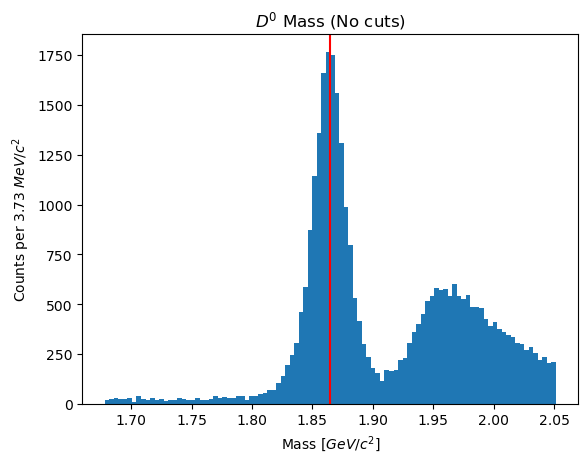

In [36]:
MIN_MASS, MAX_MASS = 0.9*m_d0, 1.1*m_d0
N_BINS = 100
only_D0= final_results["Is_This_D0"] == True
plt.hist(final_results["inv_mass"], bins=N_BINS, range=(MIN_MASS, MAX_MASS))
plt.axvline(x=m_d0, color="red")
plt.xlabel("Mass [$GeV/c^2$]")
plt.ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
plt.title("$D^0$ Mass (No cuts)")
#plt.savefig("D0_Mass_MC.png")
plt.show()

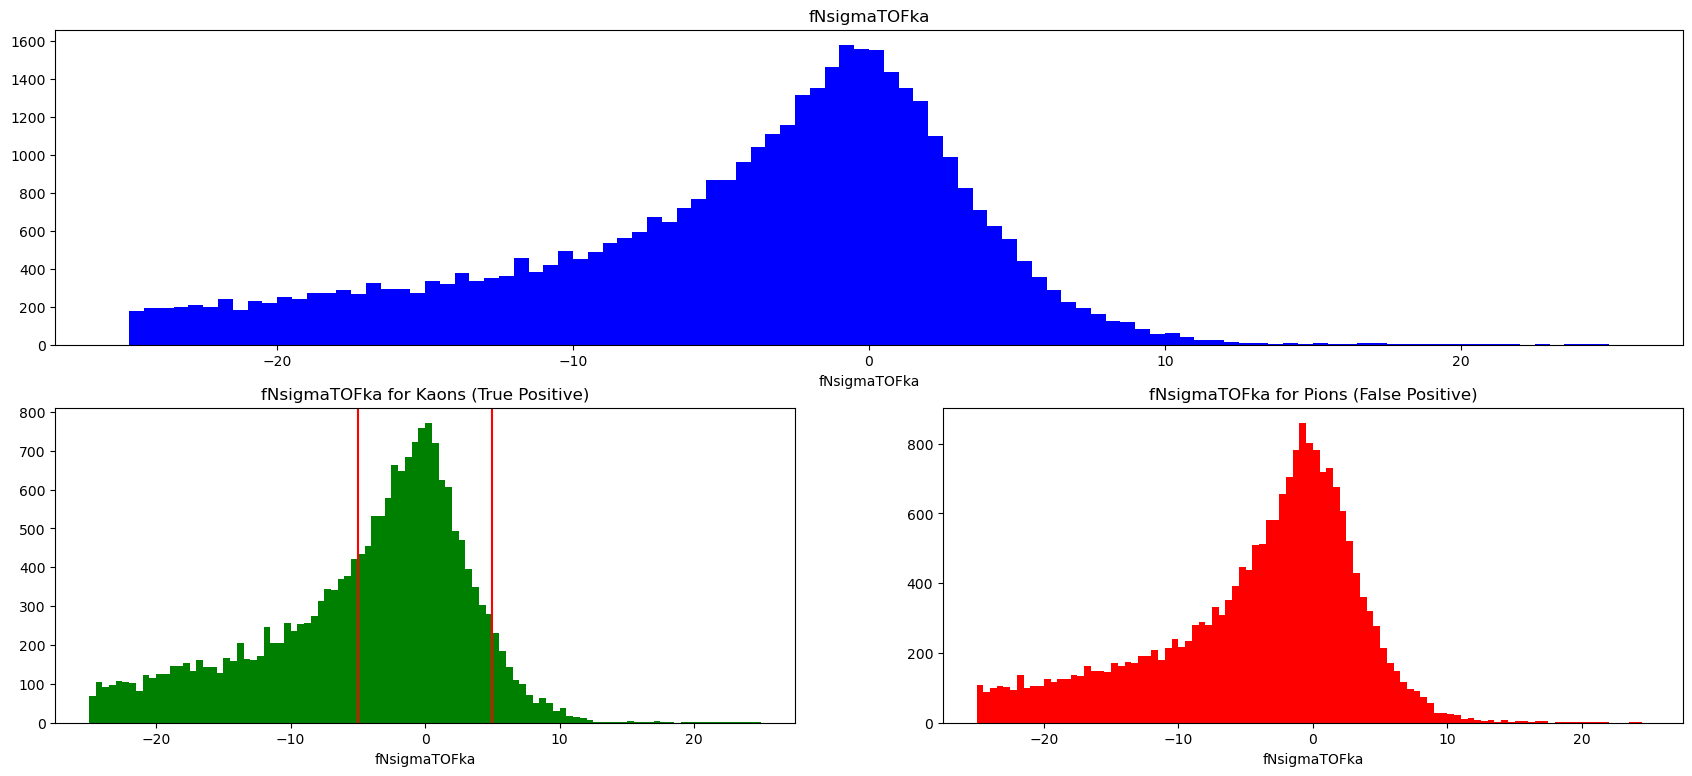

In [9]:
mosaic = [
    ["top", "top"],
    ["left", "right"]
]

fig, axes = plt.subplot_mosaic(mosaic, figsize=(21, 9))
N_BINS = 100
MIN_TOF, MAX_TOF = -25, 25
axes["top"].hist(np.concat([final_results["KA_TOFka"],final_results["PI_TOFka"]]), bins=N_BINS, color="blue", range=(MIN_TOF, MAX_TOF))
axes["top"].set_title("fNsigmaTOFka")
axes["top"].set_xlabel("fNsigmaTOFka")
axes["top"].set_label("Counts")

axes["left"].hist(final_results["KA_TOFka"], bins=N_BINS, color="green", range=(MIN_TOF, MAX_TOF))
axes["left"].set_title("fNsigmaTOFka for Kaons (True Positive)")
axes["left"].set_xlabel("fNsigmaTOFka")
axes["left"].set_label("Counts")
axes["left"].axvline(x=-5, color="red")
axes["left"].axvline(x=+5, color="red")

axes["right"].hist(final_results["PI_TOFka"], bins=N_BINS, color="red", range=(MIN_TOF, MAX_TOF))
axes["right"].set_title("fNsigmaTOFka for Pions (False Positive)")
axes["right"].set_xlabel("fNsigmaTOFka")
axes["right"].set_label("Counts")

plt.show()

---KA only---
True Positive data remaining for -3 < TOF_KA < 3:     15.90%   (40924 rows eliminated.)
True Positive data remaining for -3 < TOF_KA < 3 or unavailable:     68.42%   (15367 rows eliminated.)

---All particles---
True&False Positive data remaining for -3 < TOF_KA < 3:     13.67%   (42013 rows eliminated.)
True&False Positive data remaining for -3 < TOF_KA < 3 or unavailable:     90.16%   (4790 rows eliminated.)


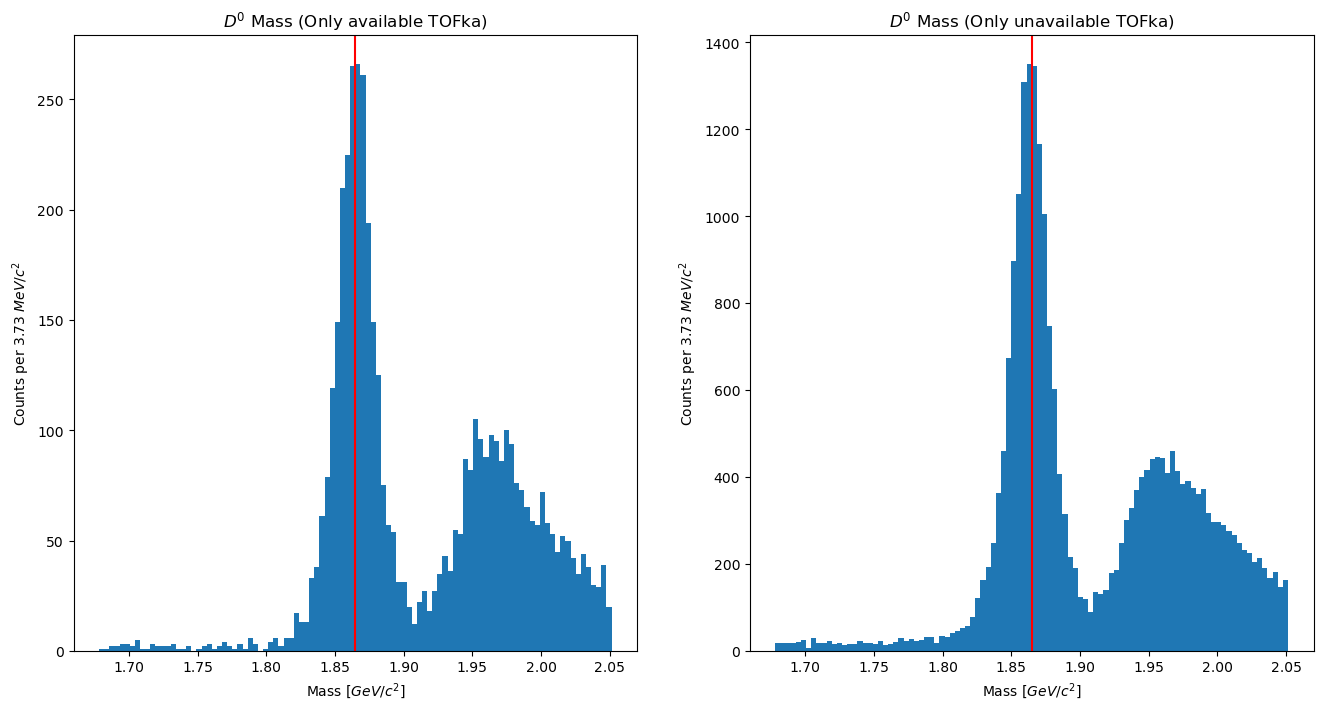

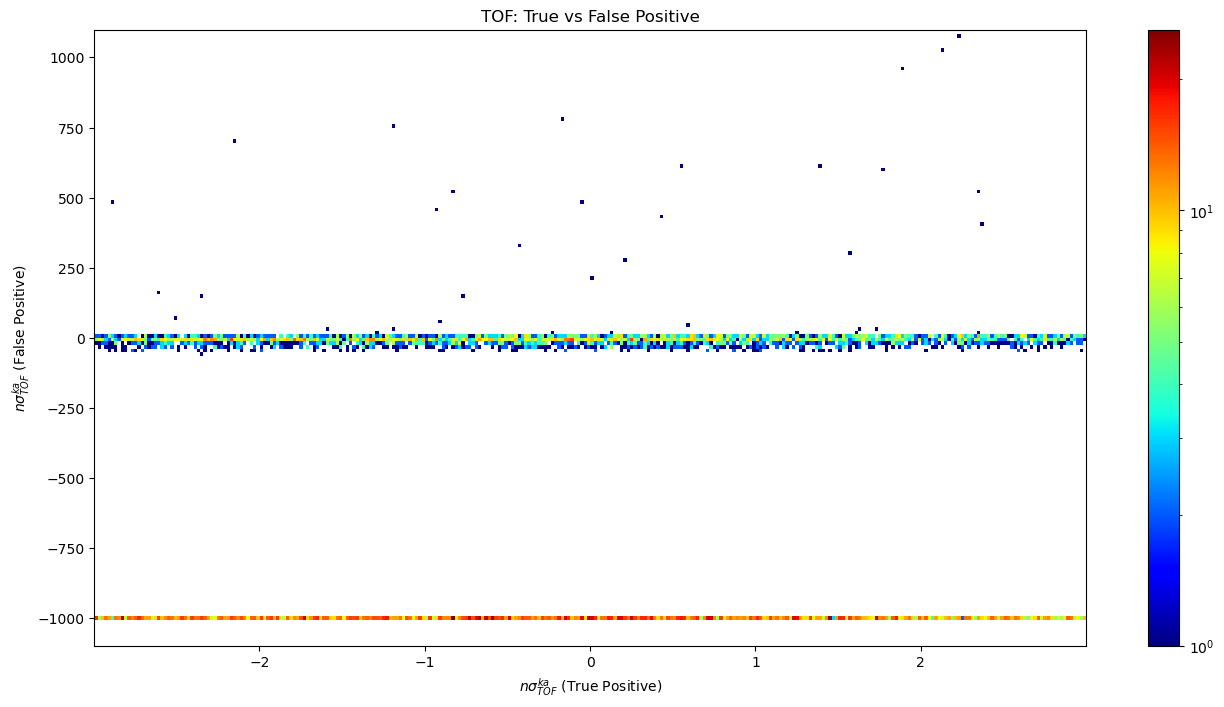

Fraction of True Positive Kaons with corresponding unavailable TOF in case of particle switch: 0.07683297714943285


In [10]:
# in cut2:
# "( (fNsigmaTOFka > -3) & (fNsigmaTOFka < 3) & (fCharge == -1) ) | "
# "( (fNsigmaTOFka > 998.5) | (fNsigmaTOFka < -998.5) |

min_cut_TOF_KA, max_cut_TOF_KA = -3, 3
NA_TOF_KA = 998.5
start_size = len(final_results)
middle_size = sum(final_results["KA_TOFka"].between(min_cut_TOF_KA, max_cut_TOF_KA))
final_size = middle_size + sum(final_results["KA_TOFka"].abs() > NA_TOF_KA )
print("---KA only---")
print(f"True Positive data remaining for {min_cut_TOF_KA} < TOF_KA < {max_cut_TOF_KA}:     {(middle_size/start_size)*100:.2f}%   ({start_size - middle_size} rows eliminated.)")
print(f"True Positive data remaining for {min_cut_TOF_KA} < TOF_KA < {max_cut_TOF_KA} or unavailable:     {(final_size/start_size)*100:.2f}%   ({start_size - final_size} rows eliminated.)")
print("\n---All particles---")
middle_size = sum( ( final_results["KA_TOFka"].between(min_cut_TOF_KA, max_cut_TOF_KA)  & (final_results["PI_TOFka"].abs() < NA_TOF_KA) ) |
                   ( final_results["PI_TOFka"].between(min_cut_TOF_KA, max_cut_TOF_KA)  & (final_results["KA_TOFka"].abs()< NA_TOF_KA) ) )
final_size = middle_size + sum( ( final_results["KA_TOFka"].abs() > NA_TOF_KA ) | ( final_results["PI_TOFka"].abs() > NA_TOF_KA ) )
print(f"True&False Positive data remaining for {min_cut_TOF_KA} < TOF_KA < {max_cut_TOF_KA}:     {(middle_size/start_size)*100:.2f}%   ({start_size - middle_size} rows eliminated.)")
print(f"True&False Positive data remaining for {min_cut_TOF_KA} < TOF_KA < {max_cut_TOF_KA} or unavailable:     {(final_size/start_size)*100:.2f}%   ({start_size - final_size} rows eliminated.)")

# Are rows corresponding to unavailable TOFka important? How does the invariant mass look without them?
only_available_TOF = final_results[( final_results["KA_TOFka"].between(min_cut_TOF_KA, max_cut_TOF_KA)  & (final_results["PI_TOFka"].abs() < NA_TOF_KA) ) |
                   ( final_results["PI_TOFka"].between(min_cut_TOF_KA, max_cut_TOF_KA)  & (final_results["KA_TOFka"].abs()< NA_TOF_KA) )]

MIN_MASS, MAX_MASS = 0.9*m_d0, 1.1*m_d0
N_BINS = 100
fig, ax  = plt.subplots(1, 2, figsize=(16,8))
ax[0].hist(only_available_TOF["inv_mass"], bins=N_BINS, range=(MIN_MASS, MAX_MASS))
ax[0].axvline(x=m_d0, color="red")
ax[0].set_xlabel("Mass [$GeV/c^2$]")
ax[0].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
ax[0].set_title("$D^0$ Mass (Only available TOFka)")

# only UNAVAILABLE
only_unavailable_TOF = final_results[( final_results["KA_TOFka"].abs() > NA_TOF_KA ) | ( final_results["PI_TOFka"].abs() > NA_TOF_KA ) ]
ax[1].hist(only_unavailable_TOF["inv_mass"], bins=N_BINS, range=(MIN_MASS, MAX_MASS))
ax[1].axvline(x=m_d0, color="red")
ax[1].set_xlabel("Mass [$GeV/c^2$]")
ax[1].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
ax[1].set_title("$D^0$ Mass (Only unavailable TOFka)")

plt.show()

# Check how the true positive and false positive are related
fig, ax = plt.subplots(figsize=(16,8))
plt.hist2d(final_results[( final_results["KA_TOFka"].between(min_cut_TOF_KA, max_cut_TOF_KA))]["KA_TOFka"],
           final_results[( final_results["KA_TOFka"].between(min_cut_TOF_KA, max_cut_TOF_KA))]["PI_TOFka"],
           (300, 300), cmap="jet", norm=LogNorm() )
plt.colorbar()
plt.xlabel(r"$n\sigma^{ka}_{TOF}$ (True Positive)")
plt.ylabel(r"$n\sigma^{ka}_{TOF}$ (False Positive)")
plt.ylim(-1.1*NA_TOF_KA, 1.1*NA_TOF_KA )
plt.title("TOF: True vs False Positive")
plt.show()

print("Fraction of True Positive Kaons with corresponding unavailable TOF in case of particle switch:",
      sum( (final_results["KA_TOFka"].between(min_cut_TOF_KA, max_cut_TOF_KA)) & ( (final_results["PI_TOFka"].abs() > NA_TOF_KA) ) )/len(final_results) )

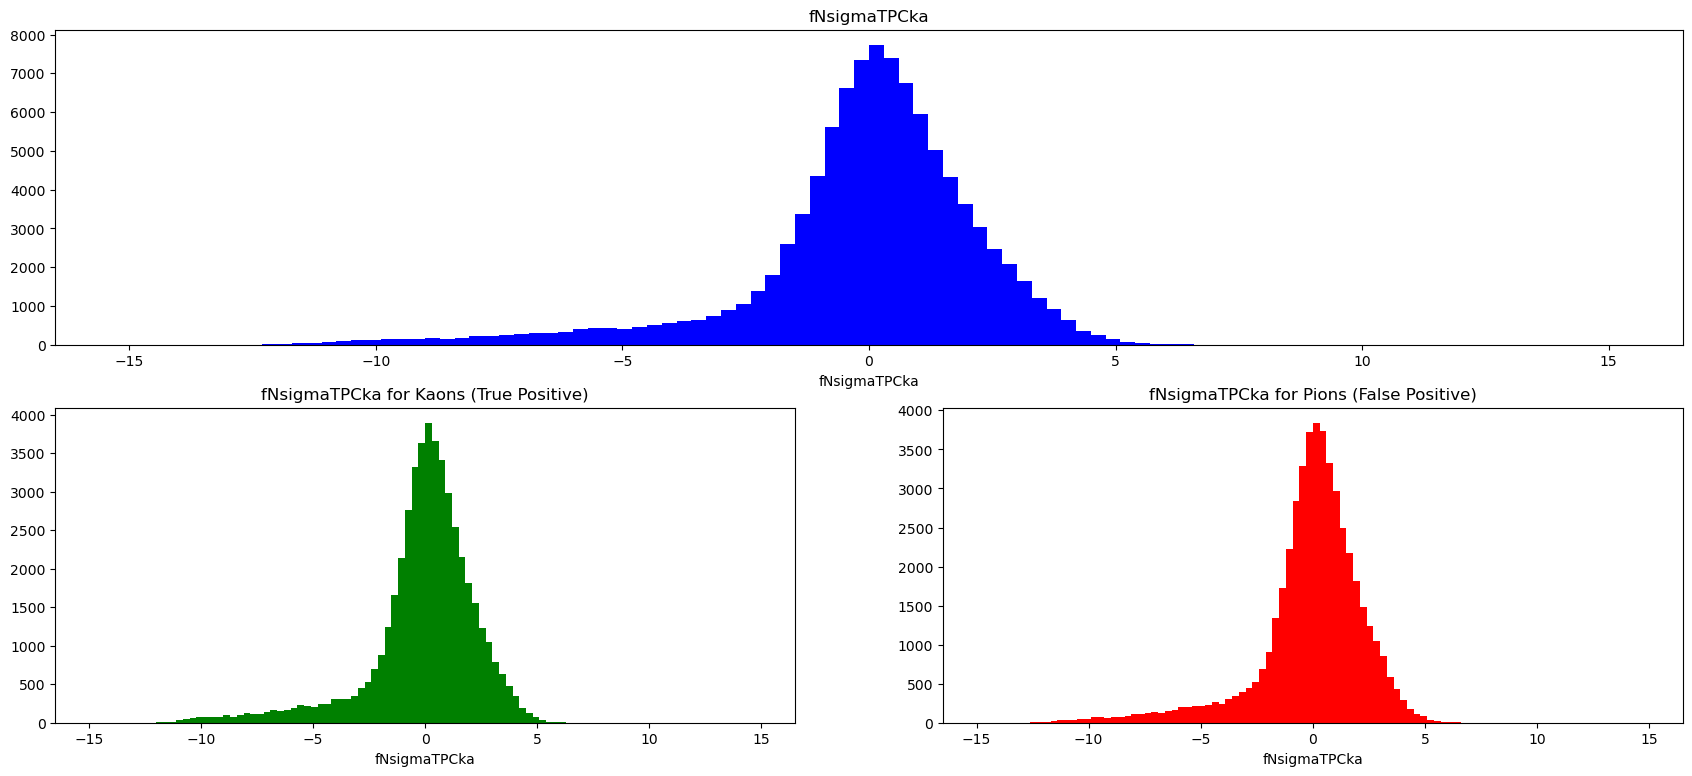

In [11]:
fig, axes = plt.subplot_mosaic(mosaic, figsize=(21, 9))
N_BINS = 100
MIN_TPC, MAX_TPC = -15, +15
axes["top"].hist(np.concat([final_results["KA_TPCka"],final_results["PI_TPCka"]]), bins=N_BINS, color="blue", range=(MIN_TPC, MAX_TPC))
axes["top"].set_title("fNsigmaTPCka")
axes["top"].set_xlabel("fNsigmaTPCka")
axes["top"].set_label("Counts")

axes["left"].hist(final_results["KA_TPCka"], bins=N_BINS, color="green", range=(MIN_TPC, MAX_TPC))
axes["left"].set_title("fNsigmaTPCka for Kaons (True Positive)")
axes["left"].set_xlabel("fNsigmaTPCka")
axes["left"].set_label("Counts")

axes["right"].hist(final_results["PI_TPCka"], bins=N_BINS, color="red", range=(MIN_TPC, MAX_TPC))
axes["right"].set_title("fNsigmaTPCka for Pions (False Positive)")
axes["right"].set_xlabel("fNsigmaTPCka")
axes["right"].set_label("Counts")

plt.show()

---KA only---
True Positive data remaining for -3 < TPC_KA < 3:     85.50%   (7054 rows eliminated.)

---All particles---
True&False Positive data remaining for -3 < TPC_KA < 3:     98.81%   (580 rows eliminated.)


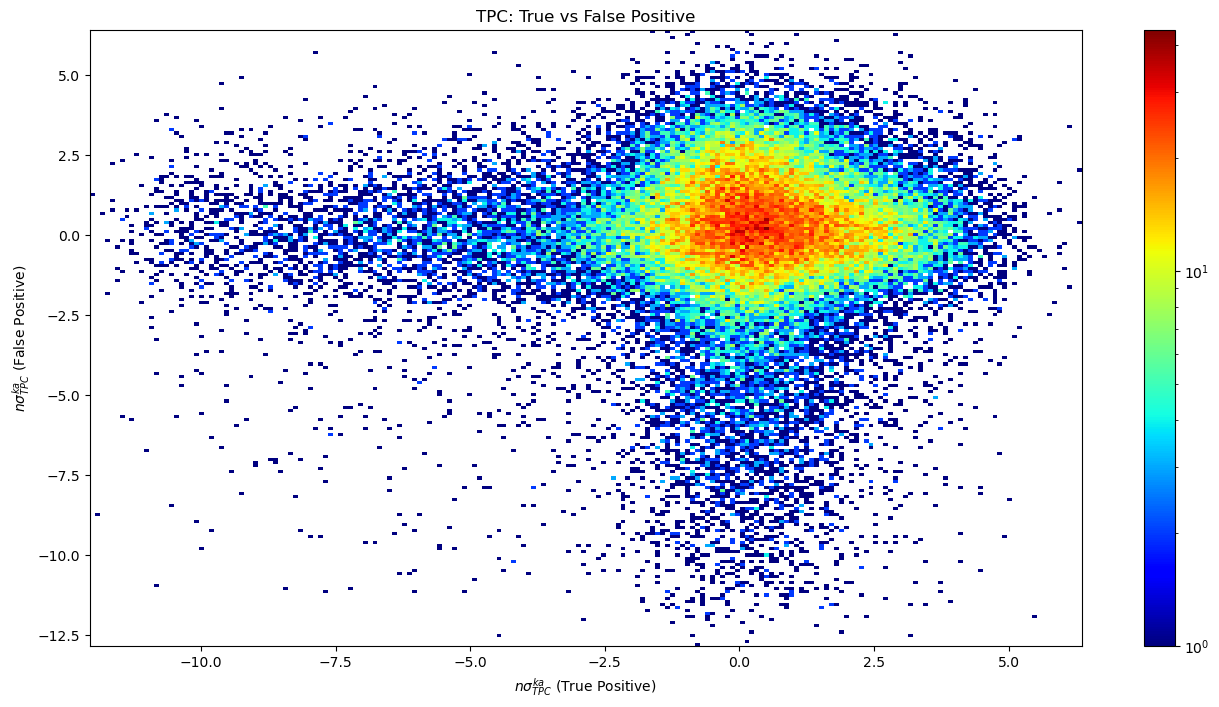

In [12]:
# in cut1:
# "( (fNsigmaTPCka > -3) & (fNsigmaTPCka < 3) & (fCharge == -1) ) | "
# "( (fPt > 0) & (fPt < 1) & (fNsigmaTPCka > -15) & (fNsigmaTPCka < 0) & (fCharge == 1) )"

min_cut_TPC_KA, max_cut_TPC_KA = -3, 3
start_size = len(final_results)
final_size = sum(final_results["KA_TPCka"].between(min_cut_TPC_KA, max_cut_TPC_KA))
print("---KA only---")
print(f"True Positive data remaining for {min_cut_TPC_KA} < TPC_KA < {max_cut_TPC_KA}:     {(final_size/start_size)*100:.2f}%   ({start_size - final_size} rows eliminated.)")
print("\n---All particles---")
final_size = sum( ( final_results["KA_TPCka"].between(min_cut_TPC_KA, max_cut_TPC_KA) ) |
                   ( final_results["PI_TPCka"].between(min_cut_TPC_KA, max_cut_TPC_KA)  ) )
print(f"True&False Positive data remaining for {min_cut_TPC_KA} < TPC_KA < {max_cut_TPC_KA}:     {(final_size/start_size)*100:.2f}%   ({start_size - final_size} rows eliminated.)")

# Check how the true positive and false positive are related
fig, ax = plt.subplots(figsize=(16,8))
plt.hist2d(final_results["KA_TPCka"], final_results["PI_TPCka"], (200, 200), cmap="jet", norm=LogNorm() )
plt.colorbar()
plt.xlabel(r"$n\sigma^{ka}_{TPC}$ (True Positive)")
plt.ylabel(r"$n\sigma^{ka}_{TPC}$ (False Positive)")
plt.title("TPC: True vs False Positive")
plt.show()

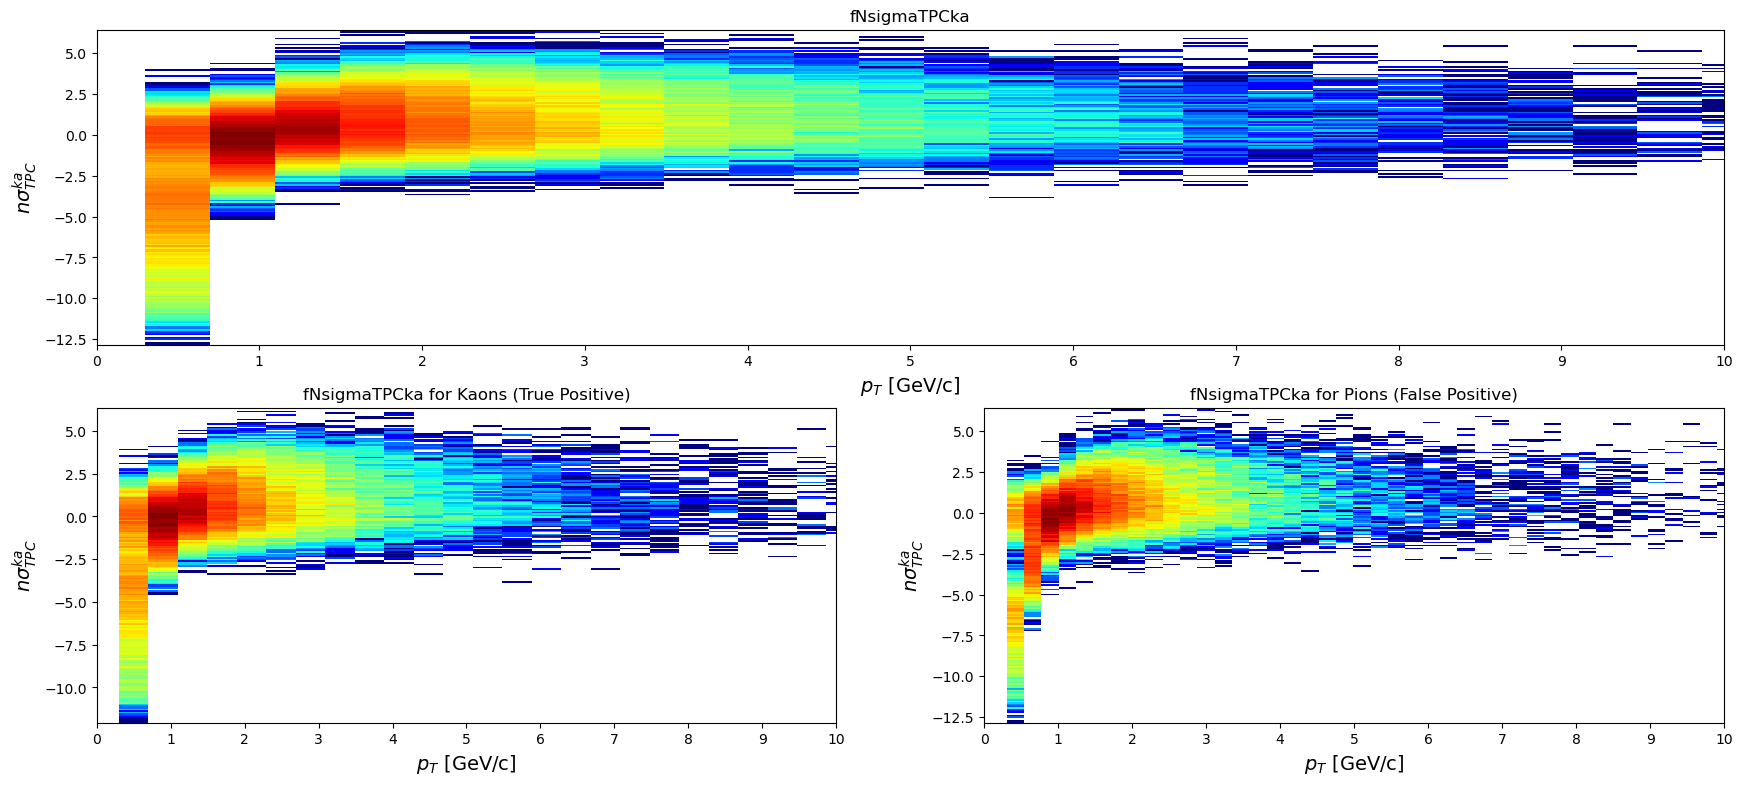

In [13]:
fs = 14
p_cut_lower = 0
p_cut_upper = 10
fig, axes = plt.subplot_mosaic(mosaic, figsize=(21, 9))
axes["top"].hist2d(np.concat([final_results["KA_pt"], final_results["PI_pt"]]),
                    np.concat([final_results["KA_TPCka"], final_results["PI_TPCka"]]), (200, 200), cmap="jet", norm=LogNorm())
# plt.colorbar(ax=axes["top"])
axes["top"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["top"].set_ylabel(r"$n\sigma^{ka}_{TPC}$", fontsize=fs)
axes["top"].set_xlim(p_cut_lower, p_cut_upper )
axes["top"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["top"].set_title("fNsigmaTPCka")


axes["left"].hist2d(final_results["KA_pt"], final_results["KA_TPCka"], (200, 200), cmap="jet", norm=LogNorm())
# plt.colorbar(ax=axes["left"])
axes["left"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["left"].set_ylabel(r"$n\sigma^{ka}_{TPC}$", fontsize=fs)
axes["left"].set_xlim(p_cut_lower, p_cut_upper )
axes["left"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["left"].set_title("fNsigmaTPCka for Kaons (True Positive)")

axes["right"].hist2d(final_results["PI_pt"], final_results["PI_TPCka"], (200, 200), cmap="jet", norm=LogNorm())
# plt.colorbar(ax=axes["left"])
axes["right"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["right"].set_ylabel(r"$n\sigma^{ka}_{TPC}$", fontsize=fs)
axes["right"].set_xlim(p_cut_lower, p_cut_upper )
axes["right"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["right"].set_title("fNsigmaTPCka for Pions (False Positive)")

plt.show()

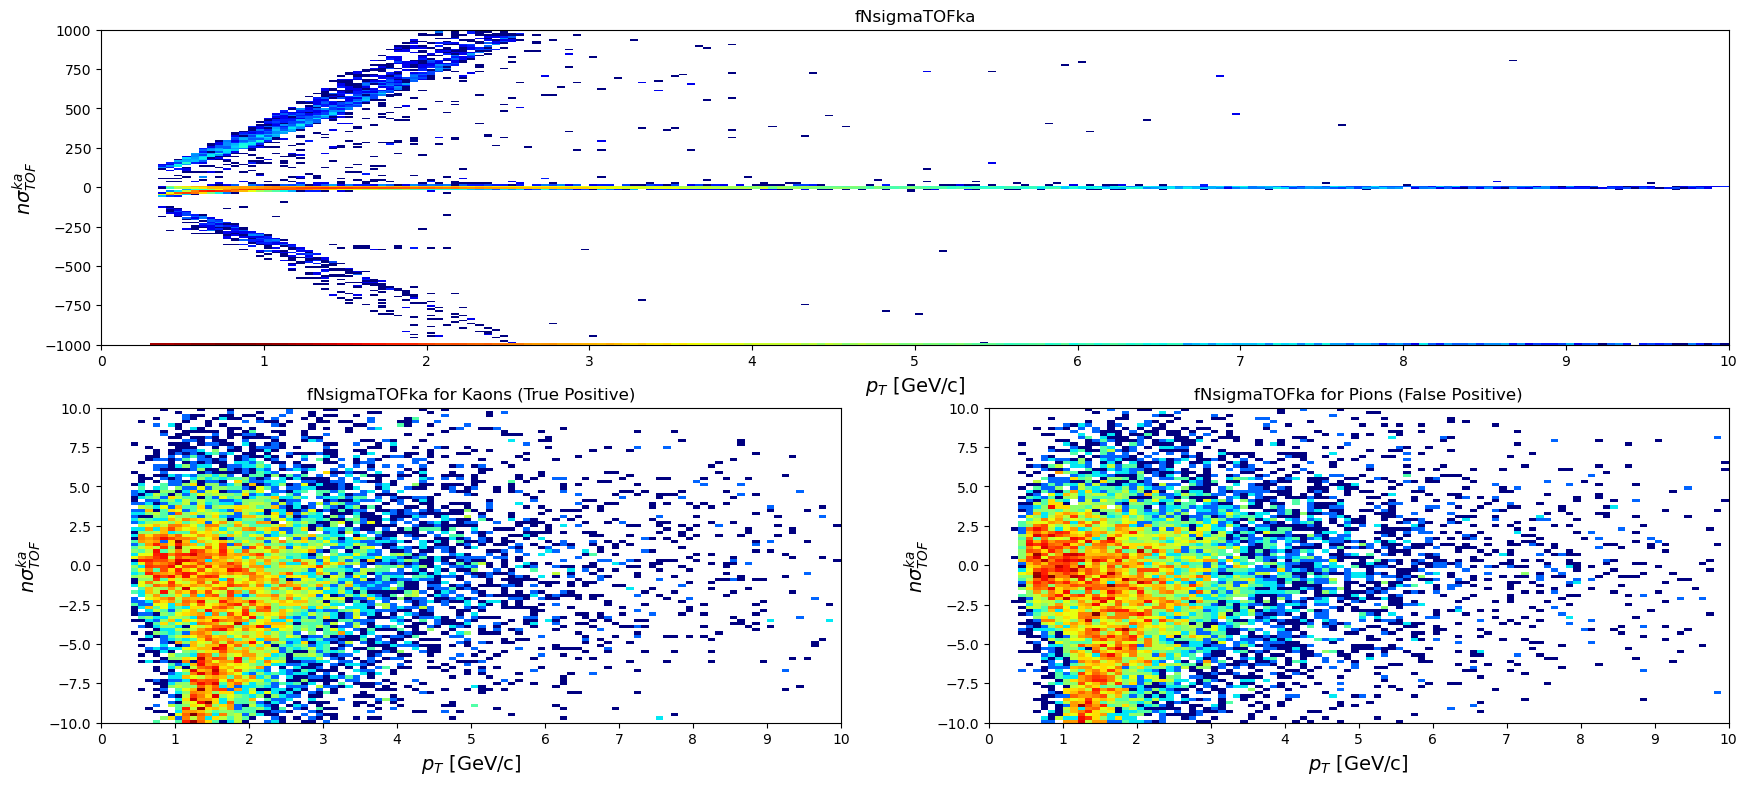

In [14]:
fs = 14
p_cut_lower = 0
p_cut_upper = 10
TOF_lower, TOF_upper = -1000, +1000
fig, axes = plt.subplot_mosaic(mosaic, figsize=(21, 9))
axes["top"].hist2d(np.concat([final_results["KA_pt"], final_results["PI_pt"]]),
                    np.concat([final_results["KA_TOFka"], final_results["PI_TOFka"]]), (200, 200), cmap="jet", norm=LogNorm(),
                    range = ([[p_cut_lower,p_cut_upper],[TOF_lower,TOF_upper]]))
# plt.colorbar(ax=axes["top"])
axes["top"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["top"].set_ylabel(r"$n\sigma^{ka}_{TOF}$", fontsize=fs)
axes["top"].set_xlim(p_cut_lower, p_cut_upper )
axes["top"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["top"].set_title("fNsigmaTOFka")


axes["left"].hist2d(final_results["KA_pt"], final_results["KA_TOFka"], (100, 100), cmap="jet", norm=LogNorm(),
                    range = ([[p_cut_lower,p_cut_upper],[-10,10]]))
# plt.colorbar(ax=axes["left"])
axes["left"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["left"].set_ylabel(r"$n\sigma^{ka}_{TOF}$", fontsize=fs)
axes["left"].set_xlim(p_cut_lower, p_cut_upper )
axes["left"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["left"].set_title("fNsigmaTOFka for Kaons (True Positive)")

axes["right"].hist2d(final_results["PI_pt"], final_results["PI_TOFka"], (100, 100), cmap="jet", norm=LogNorm(),
                     range = ([[p_cut_lower,p_cut_upper],[-10,10]]))
# plt.colorbar(ax=axes["left"])
axes["right"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["right"].set_ylabel(r"$n\sigma^{ka}_{TOF}$", fontsize=fs)
axes["right"].set_xlim(p_cut_lower, p_cut_upper )
axes["right"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["right"].set_title("fNsigmaTOFka for Pions (False Positive)")

plt.show()

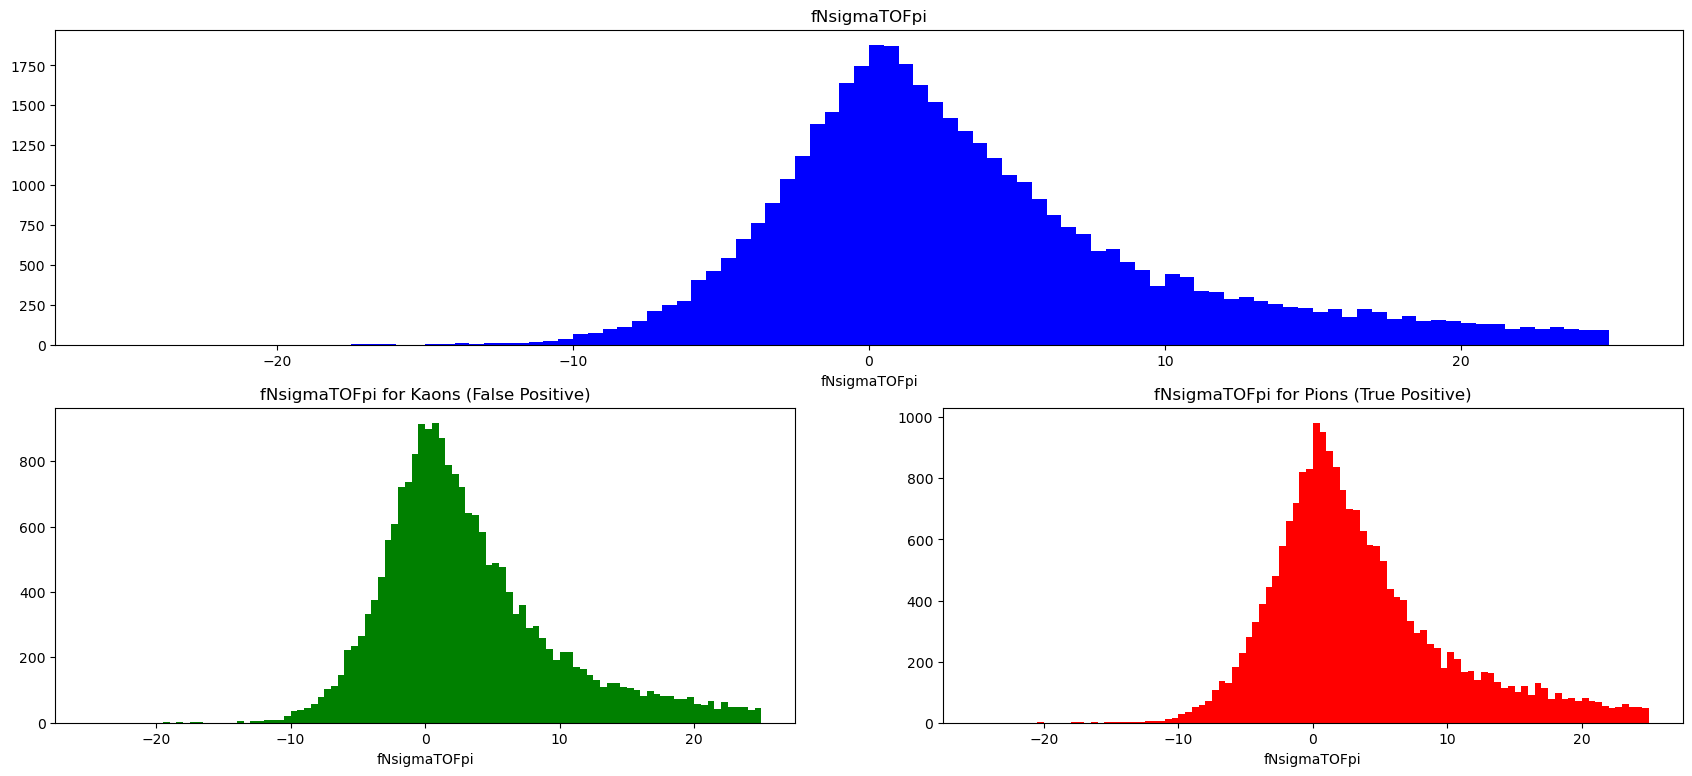

In [15]:
fig, axes = plt.subplot_mosaic(mosaic, figsize=(21, 9))
N_BINS = 100
MIN_TOF, MAX_TOF = -25, 25
axes["top"].hist(np.concat([final_results["KA_TOFpi"],final_results["PI_TOFpi"]]), bins=N_BINS, color="blue", range=(MIN_TOF, MAX_TOF))
axes["top"].set_title("fNsigmaTOFpi")
axes["top"].set_xlabel("fNsigmaTOFpi")
axes["top"].set_label("Counts")

axes["left"].hist(final_results["KA_TOFpi"], bins=N_BINS, color="green", range=(MIN_TOF, MAX_TOF))
axes["left"].set_title("fNsigmaTOFpi for Kaons (False Positive)")
axes["left"].set_xlabel("fNsigmaTOFpi")
axes["left"].set_label("Counts")

axes["right"].hist(final_results["PI_TOFpi"], bins=N_BINS, color="red", range=(MIN_TOF, MAX_TOF))
axes["right"].set_title("fNsigmaTOFpi for Pions (True Positive)")
axes["right"].set_xlabel("fNsigmaTOFpi")
axes["right"].set_label("Counts")

plt.show()

---Pion only---
True Positive data remaining for -3 < TOF_PI < 3:     18.92%   (39455 rows eliminated.)
True Positive data remaining for -3 < TOF_PI < 3 or unavailable:     72.98%   (13151 rows eliminated.)

---All particles---
True&False Positive data remaining for -3 < TOF_PI < 3:     14.17%   (41770 rows eliminated.)
True&False Positive data remaining for -3 < TOF_PI < 3 or unavailable:     91.98%   (3902 rows eliminated.)


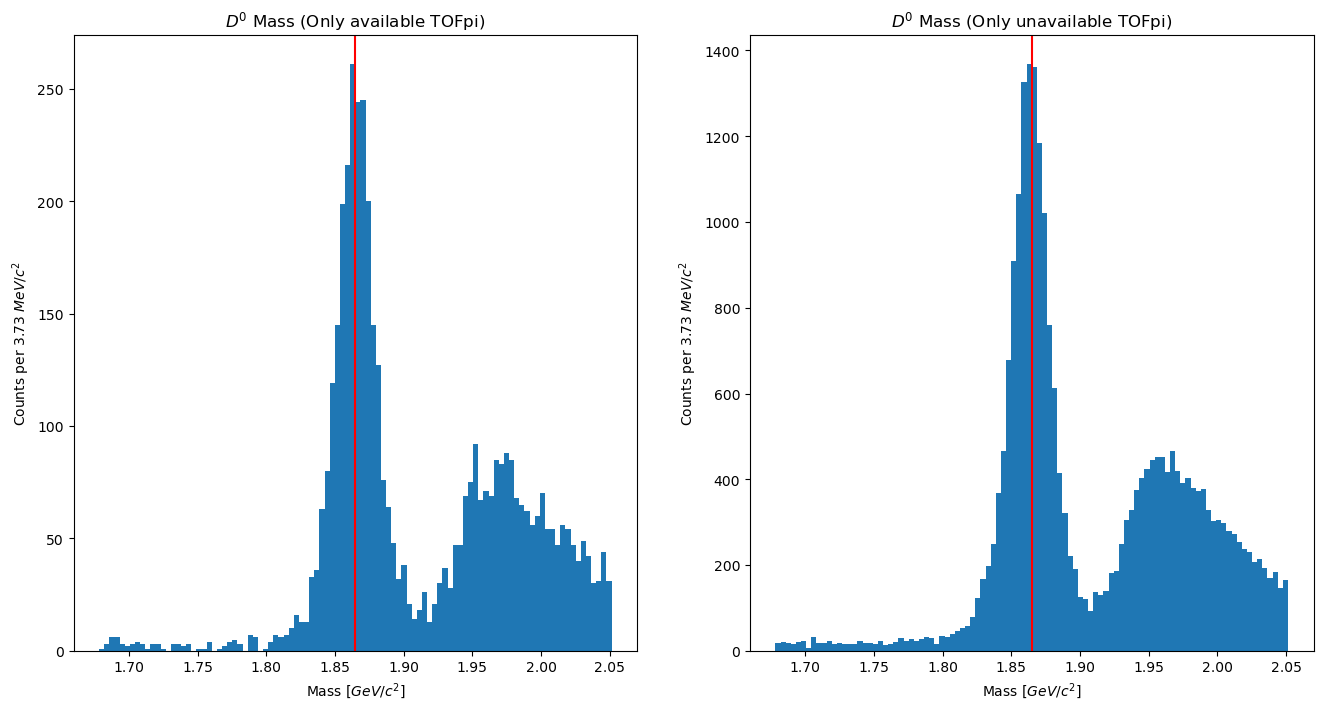

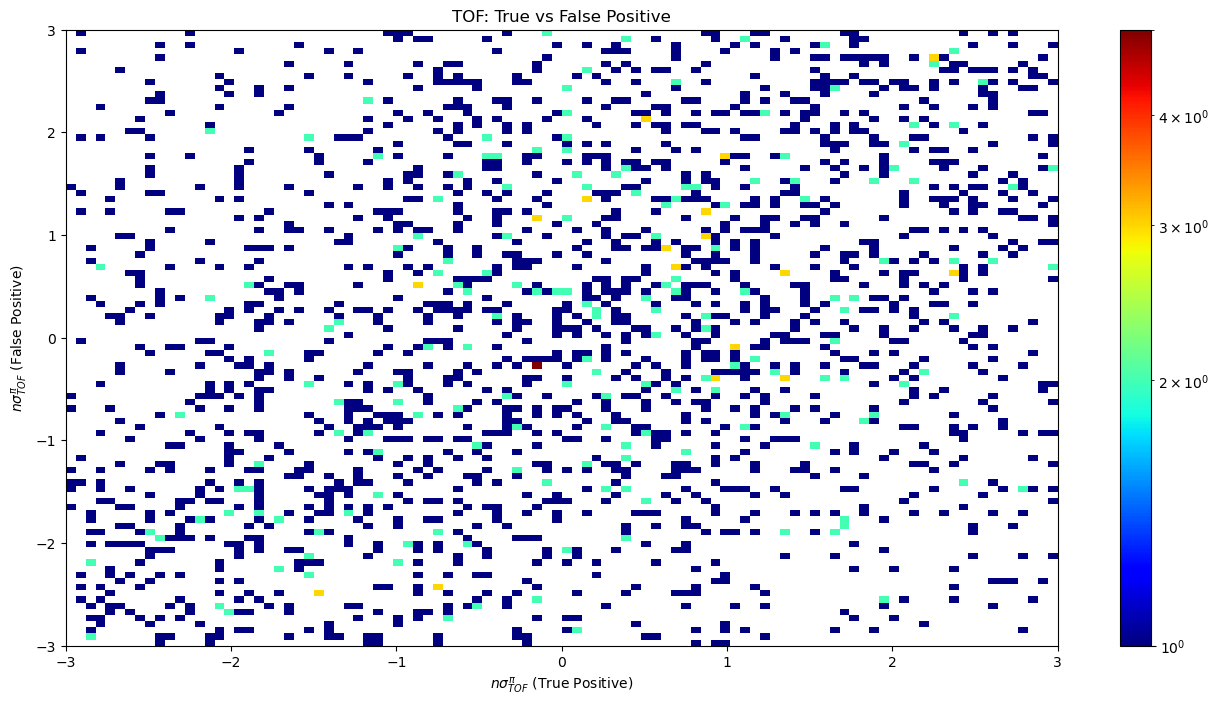

Fraction of True Positive Pions with corresponding unavailable TOF in case of particle switch: 0.09906707216833799


In [16]:
# in cut2:
# "( (fNsigmaTOFpi > -3) & (fNsigmaTOFpi < 3) & (fCharge == 1) ) | "
# "(fNsigmaTOFpi > 998.5) | (fNsigmaTOFpi < -998.5) ) | "

min_cut_TOF_PI, max_cut_TOF_PI = -3, 3
NA_TOF_PI = 998.5
start_size = len(final_results)
middle_size = sum(final_results["PI_TOFpi"].between(min_cut_TOF_PI, max_cut_TOF_PI))
final_size = middle_size + sum(final_results["PI_TOFpi"].abs() > NA_TOF_PI )
print("---Pion only---")
print(f"True Positive data remaining for {min_cut_TOF_PI} < TOF_PI < {max_cut_TOF_PI}:     {(middle_size/start_size)*100:.2f}%   ({start_size - middle_size} rows eliminated.)")
print(f"True Positive data remaining for {min_cut_TOF_PI} < TOF_PI < {max_cut_TOF_PI} or unavailable:     {(final_size/start_size)*100:.2f}%   ({start_size - final_size} rows eliminated.)")
print("\n---All particles---")
middle_size = sum( ( final_results["KA_TOFpi"].between(min_cut_TOF_PI, max_cut_TOF_PI)  & (final_results["PI_TOFpi"].abs() < NA_TOF_PI) ) |
                   ( final_results["PI_TOFpi"].between(min_cut_TOF_PI, max_cut_TOF_PI)  & (final_results["KA_TOFpi"].abs()< NA_TOF_PI) ) )
final_size = middle_size + sum( ( final_results["KA_TOFpi"].abs() > NA_TOF_PI ) | ( final_results["PI_TOFpi"].abs() > NA_TOF_PI ) )
print(f"True&False Positive data remaining for {min_cut_TOF_KA} < TOF_PI < {max_cut_TOF_KA}:     {(middle_size/start_size)*100:.2f}%   ({start_size - middle_size} rows eliminated.)")
print(f"True&False Positive data remaining for {min_cut_TOF_KA} < TOF_PI < {max_cut_TOF_KA} or unavailable:     {(final_size/start_size)*100:.2f}%   ({start_size - final_size} rows eliminated.)")

# Are rows corresponding to unavailable TOFpi important? How does the invariant mass look without them?
only_available_TOF = final_results[( final_results["KA_TOFpi"].between(min_cut_TOF_PI, max_cut_TOF_PI)  & (final_results["PI_TOFpi"].abs() < NA_TOF_PI) ) |
                   ( final_results["PI_TOFpi"].between(min_cut_TOF_PI, max_cut_TOF_PI)  & (final_results["KA_TOFpi"].abs()< NA_TOF_PI) )]

MIN_MASS, MAX_MASS = 0.9*m_d0, 1.1*m_d0
N_BINS = 100
fig, ax  = plt.subplots(1, 2, figsize=(16,8))
ax[0].hist(only_available_TOF["inv_mass"], bins=N_BINS, range=(MIN_MASS, MAX_MASS))
ax[0].axvline(x=m_d0, color="red")
ax[0].set_xlabel("Mass [$GeV/c^2$]")
ax[0].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
ax[0].set_title("$D^0$ Mass (Only available TOFpi)")

# only UNAVAILABLE
only_unavailable_TOF = final_results[( final_results["KA_TOFpi"].abs() > NA_TOF_PI ) | ( final_results["PI_TOFpi"].abs() > NA_TOF_PI ) ]
ax[1].hist(only_unavailable_TOF["inv_mass"], bins=N_BINS, range=(MIN_MASS, MAX_MASS))
ax[1].axvline(x=m_d0, color="red")
ax[1].set_xlabel("Mass [$GeV/c^2$]")
ax[1].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
ax[1].set_title("$D^0$ Mass (Only unavailable TOFpi)")

plt.show()

test = final_results[final_results["PI_TOFpi"].between(min_cut_TOF_PI, max_cut_TOF_PI)]
test = test[test["KA_TOFpi"].between(-10,10)]

# Check how the true positive and false positive are related
fig, ax = plt.subplots(figsize=(16,8))
# plt.hist2d(final_results[( final_results["PI_TOFpi"].between(min_cut_TOF_PI, max_cut_TOF_PI))]["PI_TOFpi"],
#            final_results[( final_results["PI_TOFpi"].between(min_cut_TOF_PI, max_cut_TOF_PI))]["KA_TOFpi"],
#            (400, 400), cmap="jet", norm=LogNorm() )
plt.hist2d(test["PI_TOFpi"],
           test["KA_TOFpi"],
           (100, 100), cmap="jet", norm=LogNorm(), range=[[-3, 3], [-3, 3]] )

plt.colorbar()
plt.xlabel(r"$n\sigma^{\pi}_{TOF}$ (True Positive)")
plt.ylabel(r"$n\sigma^{\pi}_{TOF}$ (False Positive)")
#plt.ylim(-1.1*NA_TOF_PI, 1.1*NA_TOF_PI )
plt.title("TOF: True vs False Positive")
plt.show()

print("Fraction of True Positive Pions with corresponding unavailable TOF in case of particle switch:",
      sum( (final_results["PI_TOFpi"].between(min_cut_TOF_PI, max_cut_TOF_PI)) & ( (final_results["KA_TOFpi"].abs() > NA_TOF_PI) ) )/len(final_results) )

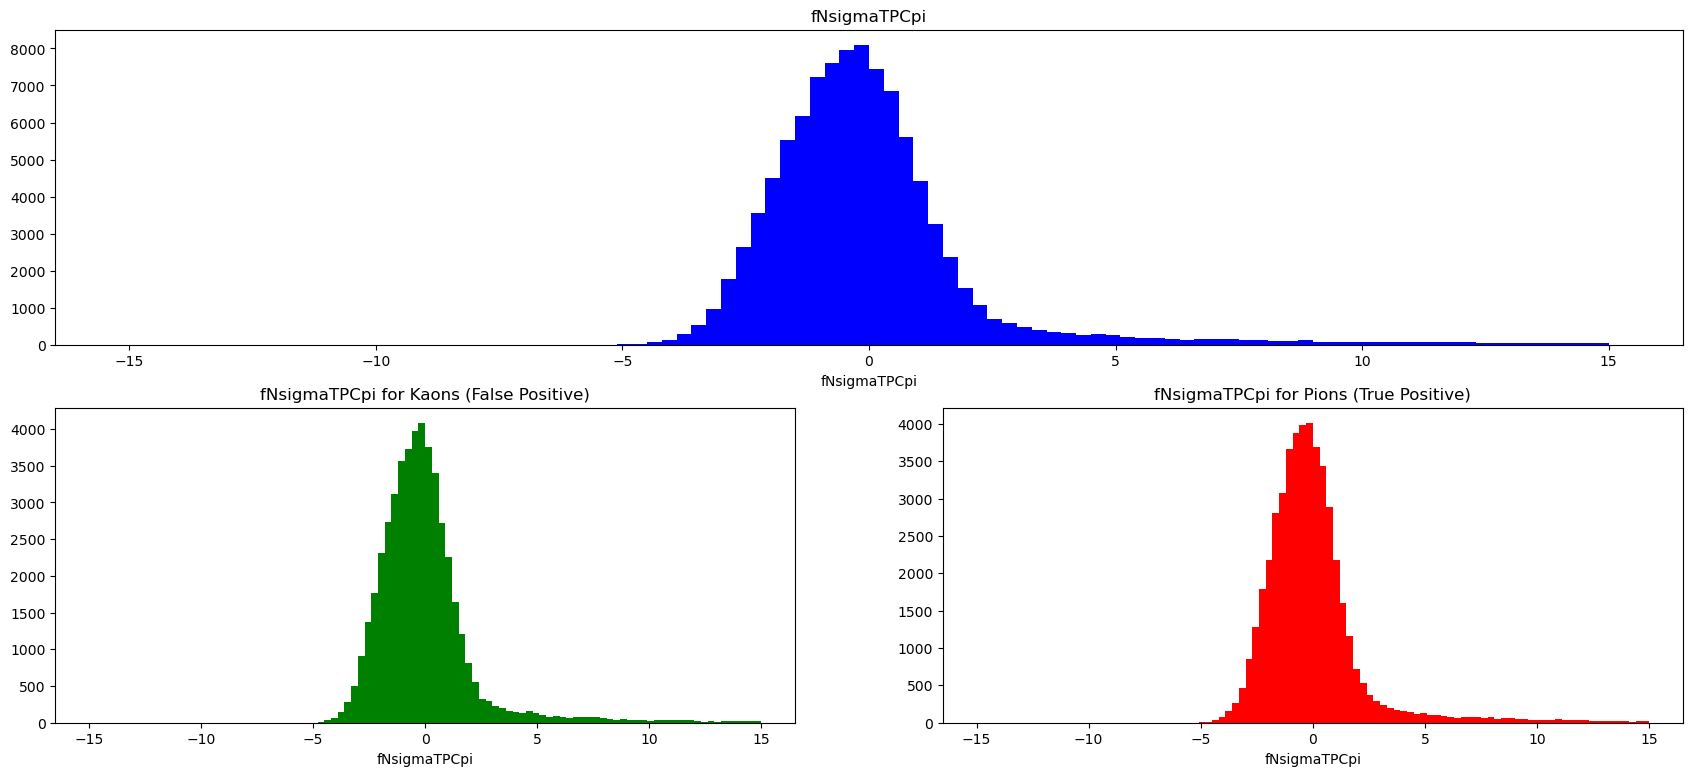

In [17]:
fig, axes = plt.subplot_mosaic(mosaic, figsize=(21, 9))
N_BINS = 100
MIN_TPC, MAX_TPC = -15, +15
axes["top"].hist(np.concat([final_results["KA_TPCpi"],final_results["PI_TPCpi"]]), bins=N_BINS, color="blue", range=(MIN_TPC, MAX_TPC))
axes["top"].set_title("fNsigmaTPCpi")
axes["top"].set_xlabel("fNsigmaTPCpi")
axes["top"].set_label("Counts")

axes["left"].hist(final_results["KA_TPCpi"], bins=N_BINS, color="green", range=(MIN_TPC, MAX_TPC))
axes["left"].set_title("fNsigmaTPCpi for Kaons (False Positive)")
axes["left"].set_xlabel("fNsigmaTPCpi")
axes["left"].set_label("Counts")

axes["right"].hist(final_results["PI_TPCpi"], bins=N_BINS, color="red", range=(MIN_TPC, MAX_TPC))
axes["right"].set_title("fNsigmaTPCpi for Pions (True Positive)")
axes["right"].set_xlabel("fNsigmaTPCpi")
axes["right"].set_label("Counts")

plt.show()

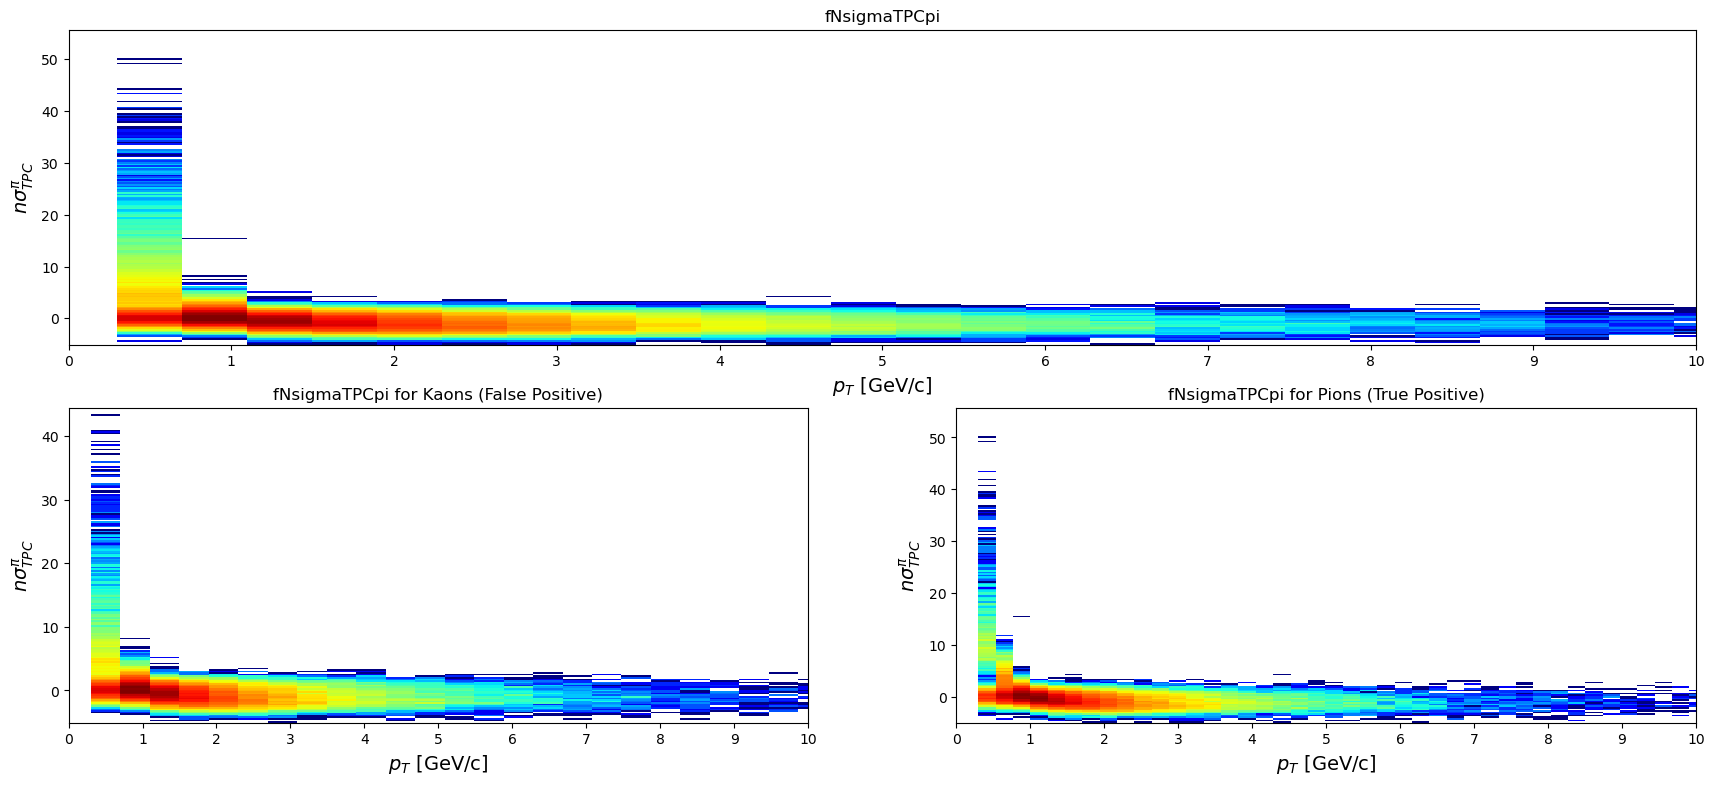

In [18]:
fs = 14
p_cut_lower = 0
p_cut_upper = 10
fig, axes = plt.subplot_mosaic(mosaic, figsize=(21, 9))
axes["top"].hist2d(np.concat([final_results["KA_pt"], final_results["PI_pt"]]),
                    np.concat([final_results["KA_TPCpi"], final_results["PI_TPCpi"]]), (200, 200), cmap="jet", norm=LogNorm())
# plt.colorbar(ax=axes["top"])
axes["top"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["top"].set_ylabel(r"$n\sigma^{\pi}_{TPC}$", fontsize=fs)
axes["top"].set_xlim(p_cut_lower, p_cut_upper )
axes["top"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["top"].set_title("fNsigmaTPCpi")


axes["left"].hist2d(final_results["KA_pt"], final_results["KA_TPCpi"], (200, 200), cmap="jet", norm=LogNorm())
# plt.colorbar(ax=axes["left"])
axes["left"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["left"].set_ylabel(r"$n\sigma^{\pi}_{TPC}$", fontsize=fs)
axes["left"].set_xlim(p_cut_lower, p_cut_upper )
axes["left"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["left"].set_title("fNsigmaTPCpi for Kaons (False Positive)")

axes["right"].hist2d(final_results["PI_pt"], final_results["PI_TPCpi"], (200, 200), cmap="jet", norm=LogNorm())
# plt.colorbar(ax=axes["left"])
axes["right"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["right"].set_ylabel(r"$n\sigma^{\pi}_{TPC}$", fontsize=fs)
axes["right"].set_xlim(p_cut_lower, p_cut_upper )
axes["right"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["right"].set_title("fNsigmaTPCpi for Pions (True Positive)")

plt.show()

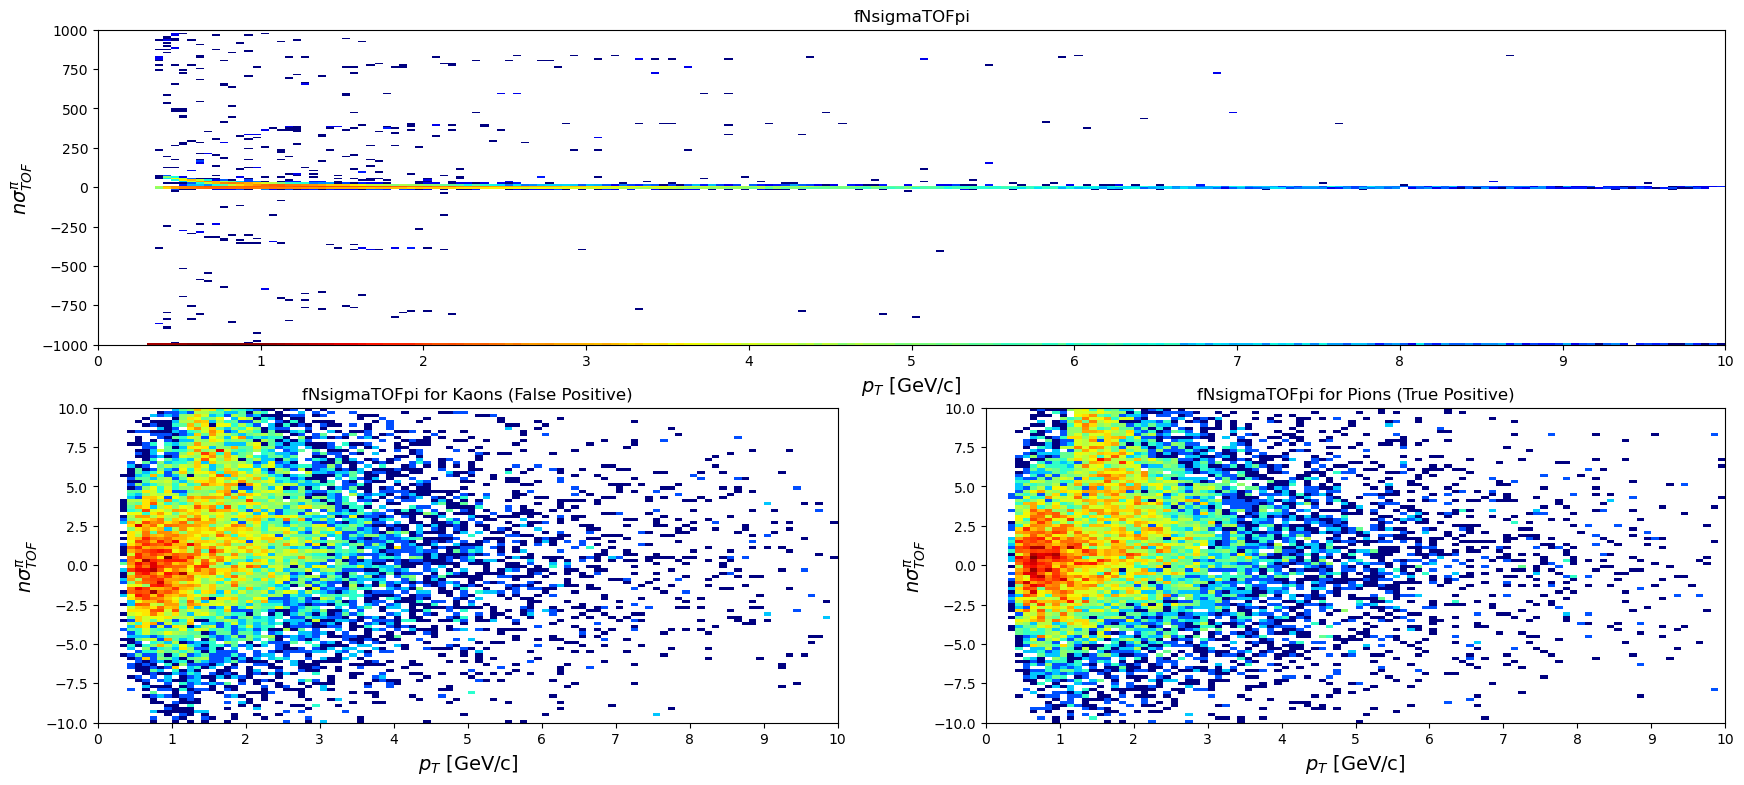

In [19]:
fs = 14
p_cut_lower = 0
p_cut_upper = 10
TOF_lower, TOF_upper = -1000, +1000
fig, axes = plt.subplot_mosaic(mosaic, figsize=(21, 9))
axes["top"].hist2d(np.concat([final_results["KA_pt"], final_results["PI_pt"]]),
                    np.concat([final_results["KA_TOFpi"], final_results["PI_TOFpi"]]), (200, 200), cmap="jet", norm=LogNorm(),
                    range = ([[p_cut_lower,p_cut_upper],[TOF_lower,TOF_upper]]))
# plt.colorbar(ax=axes["top"])
axes["top"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["top"].set_ylabel(r"$n\sigma^{\pi}_{TOF}$", fontsize=fs)
axes["top"].set_xlim(p_cut_lower, p_cut_upper )
axes["top"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["top"].set_title("fNsigmaTOFpi")


axes["left"].hist2d(final_results["KA_pt"], final_results["KA_TOFpi"], (100, 100), cmap="jet", norm=LogNorm(),
                    range = ([[p_cut_lower,p_cut_upper],[-10,10]]))
# plt.colorbar(ax=axes["left"])
axes["left"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["left"].set_ylabel(r"$n\sigma^{\pi}_{TOF}$", fontsize=fs)
axes["left"].set_xlim(p_cut_lower, p_cut_upper )
axes["left"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["left"].set_title("fNsigmaTOFpi for Kaons (False Positive)")

axes["right"].hist2d(final_results["PI_pt"], final_results["PI_TOFpi"], (100, 100), cmap="jet", norm=LogNorm(),
                     range = ([[p_cut_lower,p_cut_upper],[-10,10]]))
# plt.colorbar(ax=axes["left"])
axes["right"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["right"].set_ylabel(r"$n\sigma^{\pi}_{TOF}$", fontsize=fs)
axes["right"].set_xlim(p_cut_lower, p_cut_upper )
axes["right"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["right"].set_title("fNsigmaTOFpi for Pions (True Positive)")

plt.show()

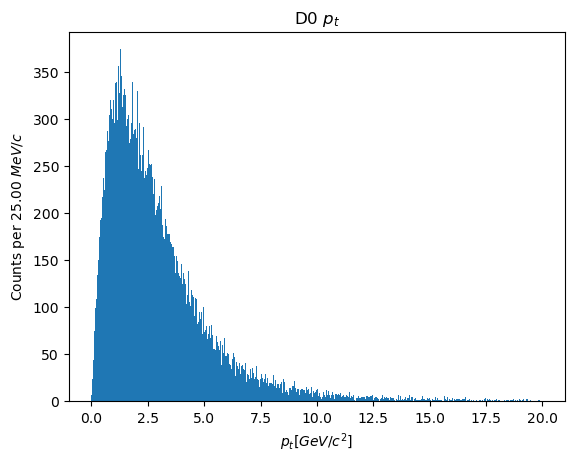

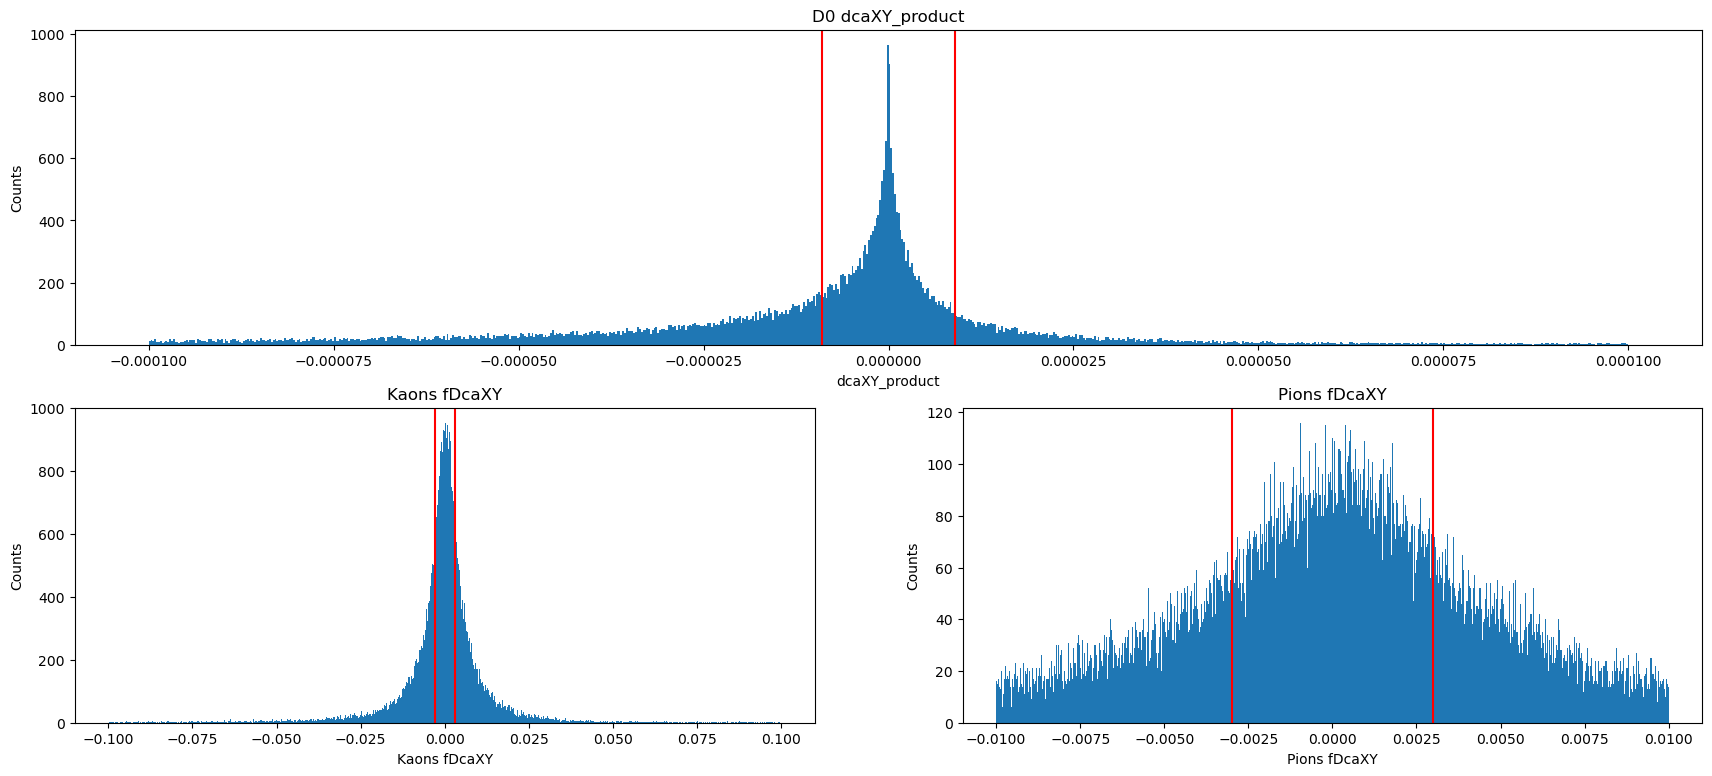

In [20]:
MIN_pt, MAX_pt = 0, 20
N_BINS = 800
plt.hist(final_results["pt"], range=(MIN_pt, MAX_pt), bins=N_BINS)
plt.xlabel("$p_t [GeV/c^2]$")
plt.ylabel(f"Counts per {((MAX_pt -  MIN_pt)/N_BINS)*1000:.2f} $MeV/c$")
plt.title("D0 $p_t$")
plt.show()

# MIN_DCAXY, MAX_DCAXY = np.quantile(final_results["dcaXY_product"], 0.01), np.quantile(final_results["dcaXY_product"], 0.99)
MIN_DCAXY, MAX_DCAXY = -1e-04, +1e-04
fig, axes = plt.subplot_mosaic(mosaic, figsize=(21, 9))
axes["top"].hist(final_results["dcaXY_product"], bins=N_BINS, range=(MIN_DCAXY, MAX_DCAXY))
axes["top"].set_xlabel("dcaXY_product")
axes["top"].set_ylabel(f"Counts")
axes["top"].set_title("D0 dcaXY_product")
axes["top"].axvline(x=-3e-03**2, color="red")
axes["top"].axvline(x=+3e-03**2, color="red")

axes["left"].hist(final_results["KA_fDcaXY"], bins=N_BINS, range=(-0.1,0.1) )
axes["left"].set_xlabel("Kaons fDcaXY")
axes["left"].set_ylabel(f"Counts")
axes["left"].set_title("Kaons fDcaXY")
axes["left"].axvline(x=-3e-03, color="red")
axes["left"].axvline(x=+3e-03, color="red")

axes["right"].hist(final_results["PI_fDcaXY"], bins=N_BINS, range=(-np.sqrt(-MIN_DCAXY),np.sqrt(MAX_DCAXY)))
axes["right"].set_xlabel("Pions fDcaXY")
axes["right"].set_ylabel(f"Counts")
axes["right"].set_title("Pions fDcaXY")
axes["right"].axvline(x=-3e-03, color="red")
axes["right"].axvline(x=+3e-03, color="red")
plt.show()

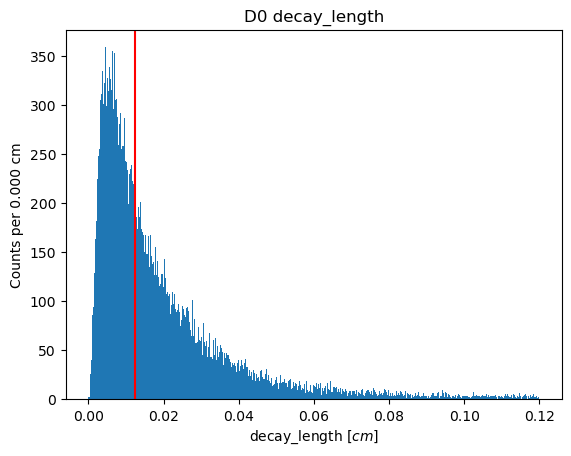

In [21]:
MIN_dl, MAX_dl = 0, 0.12
N_BINS = 800
plt.hist(final_results["decay_length"], bins=N_BINS, range=(MIN_dl, MAX_dl))
plt.xlabel("decay_length $[cm]$")
plt.ylabel(f"Counts per {((MAX_dl - MIN_dl)/N_BINS):.3f} cm")
plt.axvline(x=1.23*10e-03, color="red")
plt.title("D0 decay_length")
plt.show()

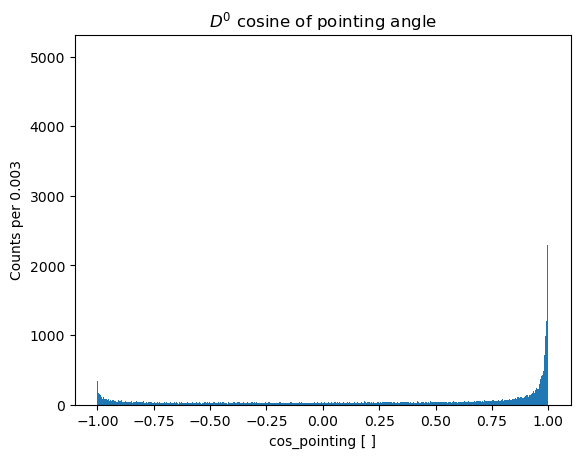

In [22]:
MIN_cos, MAX_cos = -1, 1
N_BINS = 800
plt.hist(final_results["cos_pointing"], bins=N_BINS, range=(MIN_cos, MAX_cos))
plt.xlabel("cos_pointing [ ]")
plt.ylabel(f"Counts per {((MAX_cos - MIN_cos)/N_BINS):.3f}")
plt.title("$D^0$ cosine of pointing angle")
plt.show()

In [23]:
# converting the cuts to work for this
# cut1 = (
#     "( (fNsigmaTPCpi > -3) & (fNsigmaTPCpi < 3) & (fCharge == 1) ) | "
#     "( (fNsigmaTPCka > -3) & (fNsigmaTPCka < 3) & (fCharge == -1) ) | "
#     "( (fPt > 0) & (fPt < 1) & (fNsigmaTPCka > -15) & (fNsigmaTPCka < 0) & (fCharge == 1) )"
# )

# # NsigmaTOF:
# sigma_limit = 3
# cut2 = (
#     "( (fNsigmaTOFpi > -3) & (fNsigmaTOFpi < 3) & (fCharge == 1) ) | "
#     "( (fNsigmaTOFka > -3) & (fNsigmaTOFka < 3) & (fCharge == -1) ) | "
#     "( (fNsigmaTOFka > 998.5) | (fNsigmaTOFka < -998.5) | (fNsigmaTOFpi > 998.5) | (fNsigmaTOFpi < -998.5) ) | "
#     "( (fPt > 0) & (fPt < 3) & (fNsigmaTOFka > -50) & (fNsigmaTOFka < 0) & (fCharge == 1) )"
# )

# # DCA_XY:
# cut3 = "( (fDcaXY > 0.0002) | (fDcaXY < -0.0002) )"


# # FINAL CUT EXPRESSION:
# cut_expression = f"({cut1}) & ({cut2}) & ({cut3})"

TOF_cut = 5
TPC_cut = 3
DCA_cut = 3e-03

cut1_A = final_results["PI_TPCpi"].between(-TPC_cut, +TPC_cut)
cut1_B = final_results["KA_TPCka"].between(-TPC_cut, +TPC_cut)
cut1_C = ( final_results["PI_pt"].between(0,1) ) & (final_results["KA_TPCka"].between(-15,0) )

cut1 = cut1_A | cut1_B | cut1_C

cut2_A = final_results["PI_TOFpi"].between(-TOF_cut, +TOF_cut)
cut2_B = final_results["KA_TOFka"].between(-TOF_cut, +TOF_cut)
cut2_C = ( np.isclose(final_results["PI_TOFpi"], -999.0) ) | ( np.isclose(final_results["KA_TOFka"], -999.0) )
cut2_D = ( final_results["PI_pt"].between(0,3) ) & (final_results["KA_TOFka"].between(-50,0) )

cut2 = cut2_A | cut2_B | cut2_C | cut2_D

cut3 = ( final_results["KA_fDcaXY"].abs() >= DCA_cut ) & ( final_results["PI_fDcaXY"].abs() >= DCA_cut )

final_cut = cut1 & cut2 & cut3

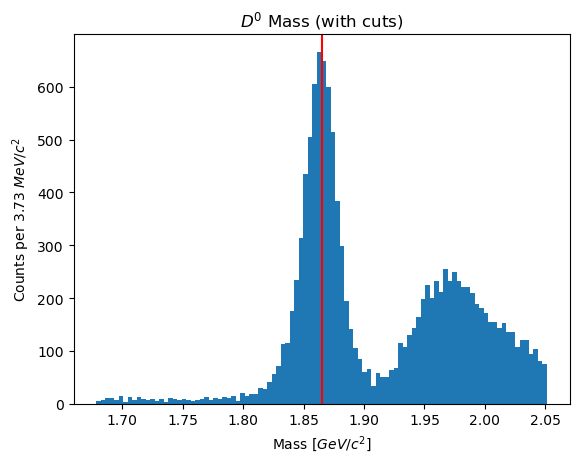

Amount of remaining data after cuts: 36.42%


,1A,1B,1C,2A,2B,2C,2D,TOT_1,TOT_2,TOT_3,FINAL
0,0.912584,0.855047,0.13548,0.269974,0.226554,0.751993,0.27207,0.986787,0.961409,0.394213,0.364171


In [24]:
MIN_MASS, MAX_MASS = 0.9*m_d0, 1.1*m_d0
N_BINS = 100
plt.hist(final_results[final_cut]["inv_mass"], bins=N_BINS, range=(MIN_MASS, MAX_MASS))
plt.axvline(x=m_d0, color="red")
plt.xlabel("Mass [$GeV/c^2$]")
plt.ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
plt.title("$D^0$ Mass (with cuts)")
#plt.savefig("D0_Mass_MC.png")
plt.show()
print(f"Amount of remaining data after cuts: {sum(final_cut)/len(final_results)*100:.2f}%")

cut_effect = pd.DataFrame({
    "1A": sum(cut1_A)/len(final_results),
    "1B": sum(cut1_B)/len(final_results),
    "1C": sum(cut1_C)/len(final_results),
    "2A": sum(cut2_A)/len(final_results),
    "2B": sum(cut2_B)/len(final_results),
    "2C": sum(cut2_C)/len(final_results),
    "2D": sum(cut2_D)/len(final_results),
    "TOT_1": sum(cut1)/len(final_results),
    "TOT_2": sum(cut2)/len(final_results),
    "TOT_3":  sum(cut3)/len(final_results),
    "FINAL": sum(final_cut)/len(final_results)
}, index=[0])
display(cut_effect)

In [25]:
final_results

,Is_This_D0,collision_index,dcaXY_product,inv_mass,anti_mass,pt,pz,decay_length,cos_pointing,KA_pt,...,KA_TOFka,KA_fDcaXY,PI_pt,PI_TPCpi,PI_TOFpi,PI_fDcaXY,KA_TPCpi,KA_TOFpi,PI_TPCka,PI_TOFka
0,True,66,-1.321097e-06,1.860440,2.056351,4.713480,2.997023,0.012976,0.964281,3.461287,...,-999.000000,0.000163,1.545394,0.057667,1.594764,-0.008085,-2.909040,-999.000000,1.663699,-6.424459
1,False,82,-2.573491e-06,2.078850,1.844297,2.841766,-0.914937,0.004732,0.896998,0.728356,...,-24.600008,0.001744,2.354507,-1.395078,2.593124,-0.001476,0.184003,-1.417414,0.563006,-1.020310
2,True,157,-7.651521e-06,1.888459,2.094230,2.195002,-0.055988,0.005348,0.617997,2.055277,...,-10.559840,0.004370,0.635137,-0.802778,-999.000000,-0.001751,-2.549568,-5.819521,-3.810798,-999.000000
3,True,235,3.273250e-05,2.758509,2.779766,0.623883,0.007970,0.037103,0.784885,1.382096,...,-6.320635,0.003012,0.927068,-0.019558,2.644639,0.010867,-0.458876,3.163080,0.435403,-13.365459
4,True,235,-5.612233e-06,1.191944,1.226901,2.550970,-0.787728,0.008647,0.963760,1.382096,...,-6.320635,0.003012,1.277296,0.573825,-999.000000,-0.001863,-0.458876,3.163080,1.178158,-999.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48659,True,3246794,-6.777133e-06,2.277701,2.314162,3.056641,0.974706,0.011953,0.783787,2.229015,...,-8.945634,-0.009737,1.522426,0.743161,-4.576275,0.000696,-0.222224,-4.846432,1.643259,-12.510291
48660,False,3246794,-2.798869e-05,2.129502,1.879726,9.072687,4.670576,0.044078,0.999820,2.229015,...,-8.945634,-0.009737,6.933897,-3.234479,-999.000000,0.002874,-0.222224,-4.846432,-1.461326,-999.000000
48661,False,3246798,4.130047e-07,1.923444,1.832013,3.655294,0.484583,0.005543,-0.962037,2.472695,...,-2.329287,-0.000198,1.233602,-1.337071,10.705864,-0.002090,1.110215,0.952291,-0.874114,-1.945005
48662,True,3246866,-1.465046e-06,1.849266,1.981853,3.204147,0.819941,0.004777,0.588302,1.788209,...,-999.000000,0.000859,1.631197,0.927404,-999.000000,-0.001706,-0.398352,-999.000000,2.473562,-999.000000


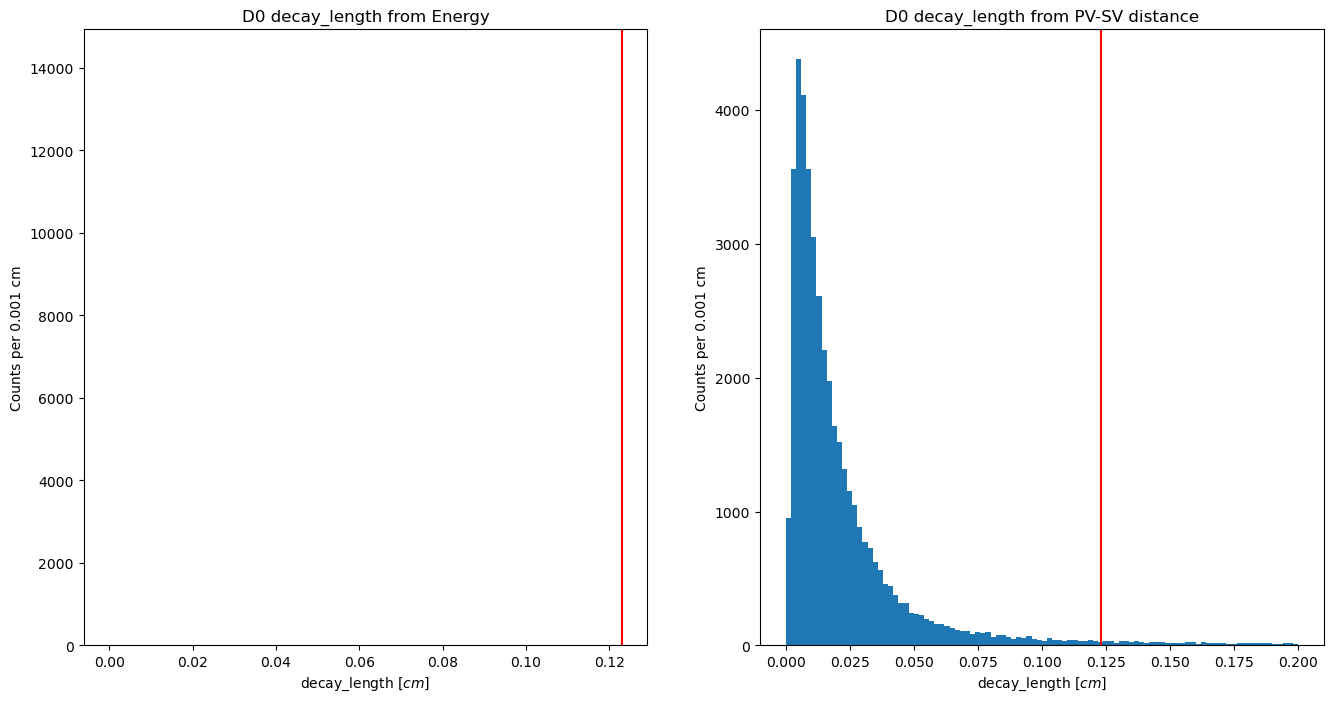

In [26]:
c = 299_792_458
tau = 410e-15

extra = pd.DataFrame({
    "P": np.sqrt( final_results["pt"]**2 + final_results["pz"]**2 )
})
extra["E"] = np.sqrt(final_results["inv_mass"]**2*c**4 + extra["P"]**2*c**2)
extra["Beta"] = extra["P"]*c/extra["E"]
gamma = 1.0/np.sqrt(1-extra["Beta"]**2)

ctau = c*tau
extra["L"] =  extra["Beta"]*gamma*ctau
fix, ax = plt.subplots(1,2, figsize=(16,8))
ax[0].hist(extra["L"], bins=N_BINS)
ax[0].set_xlabel("decay_length $[cm]$")
ax[0].set_ylabel(f"Counts per {((MAX_dl - MIN_dl)/N_BINS):.3f} cm")
ax[0].axvline(x=1.23*10e-02, color="red")
ax[0].set_title("D0 decay_length from Energy")

ax[1].hist(final_results["decay_length"], bins=N_BINS, range=(0, 0.20))
ax[1].set_xlabel("decay_length $[cm]$")
ax[1].set_ylabel(f"Counts per {((MAX_dl - MIN_dl)/N_BINS):.3f} cm")
ax[1].axvline(x=1.23*10e-02, color="red")
ax[1].set_title("D0 decay_length from PV-SV distance")
plt.show()

In [27]:
len(final_results[ final_results["PI_TOFpi"].between(-TOF_cut, +TOF_cut) | final_results["KA_TOFka"].between(-TOF_cut, +TOF_cut) ])/len(final_results)

0.413940489889857

In [31]:
sum(final_results["Is_This_D0"])/len(final_results)

np.float64(0.5133568962682886)

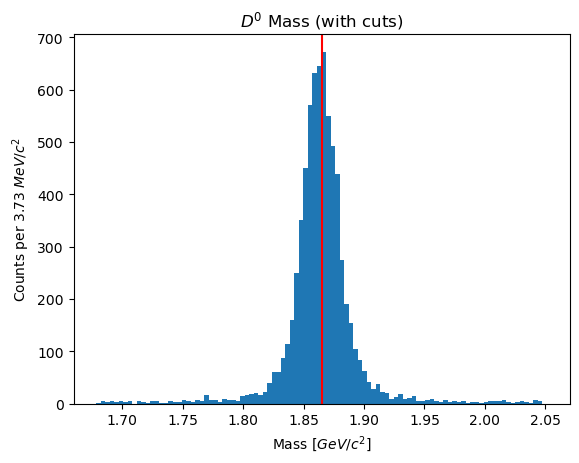

Amount of remaining data after cuts: 36.42%


In [34]:
MIN_MASS, MAX_MASS = 0.9*m_d0, 1.1*m_d0
N_BINS = 100
is_this_anti_D0 = final_results["Is_This_D0"] == False
plt.hist(final_results[is_this_anti_D0 & final_cut]["anti_mass"], bins=N_BINS, range=(MIN_MASS, MAX_MASS))
plt.axvline(x=m_d0, color="red")
plt.xlabel("Mass [$GeV/c^2$]")
plt.ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
plt.title("$D^0$ Mass (with cuts)")
#plt.savefig("D0_Mass_MC.png")
plt.show()
print(f"Amount of remaining data after cuts: {sum(final_cut)/len(final_results)*100:.2f}%")

In [ ]:
#CHECK